In [5]:
%%bash
set -e

echo "Forcing install of ML/NLP package pins (numpy<2.0.0, pandas<3.0.0, etc.)."
echo
echo "If you require geo/image/jax libraries, this pipeline is NOT compatible - skip or use another environment."
echo

pip install -q --upgrade pip

pip install --no-cache-dir --force-reinstall -q \
  "numpy<2.0.0" \
  "scipy<1.13" \
  "pandas<3.0.0" \
  "scikit-learn" \
  huggingface_hub \
  "transformers<5.0" \
  accelerate \
  sentence-transformers \
  dspy-ai \
  cleanlab \
  datasets \
  fastembed \
  openai \
  google-genai \
  "setfit<1.8" \
  tqdm \
  optuna \
  gepa

echo
echo "Note: Ignore dependency conflict warnings about numpy, pandas, or pydantic. These are expected when overriding system/Colab packages. If you are still seeing import errors, restart your runtime/kernel, then run this cell again before any imports."
echo

cat <<'EOF'
----------------------------------------------------------------------
WARNING: Potential import errors due to known incompatibilities between
'setfit' >=1.8, 'transformers' >=4.40, and new versions of 'sentence_transformers'.
If you encounter a RuntimeError or ImportError referencing torchcodec or
'Could not load libtorchcodec', this is a symptom of incompatible library versions.

  → If you see ImportError when importing setfit, or RuntimeError re: torchcodec/libtorchcodec:
      1. Ensure 'setfit<1.8', 'transformers<5.0', 'sentence-transformers', 'scikit-learn' are installed.
      2. Restart your runtime/kernel and re-run this install cell before any imports.
      3. If you still see the error, you may need to use Python 3.10/3.11
         or try downgrading torch (e.g., torch==2.1.1).

----------------------------------------------------------------------
Other pip dependency warnings are expected when overriding Colab/system packages.

If you continue to see `ModuleNotFoundError: No module named 'numpy.strings'`
or other numpy/scipy import errors, try restarting your runtime/kernel and 
rerun this install cell before any imports.

NOTE: If your import is failing due to a missing package, you can manually install dependencies using either !pip or !apt.

To view examples of installing some common dependencies, click the
"Open Examples" button below.
----------------------------------------------------------------------
EOF

Forcing install of ML/NLP package pins (numpy<2.0.0, pandas<3.0.0, etc.).

If you require geo/image/jax libraries, this pipeline is NOT compatible - skip or use another environment.


Note: Ignore dependency conflict warnings about numpy, pandas, or pydantic. These are expected when overriding system/Colab packages. If you are still seeing import errors, restart your runtime/kernel, then run this cell again before any imports.

----------------------------------------------------------------------
'setfit' >=1.8, 'transformers' >=4.40, and new versions of 'sentence_transformers'.
If you encounter a RuntimeError or ImportError referencing torchcodec or
'Could not load libtorchcodec', this is a symptom of incompatible library versions.

  → If you see ImportError when importing setfit, or RuntimeError re: torchcodec/libtorchcodec:
      1. Ensure 'setfit<1.8', 'transformers<5.0', 'sentence-transformers', 'scikit-learn' are installed.
      2. Restart your runtime/kernel and re-run this i

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
google-colab 1.0.0 requires google-auth==2.47.0, but you have google-auth 2.52.0 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 48.0.0 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.34.1 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 48.0.0 which is incomp

#### Init

In [8]:
# Colab setup: install dependencies, mount Drive, and load secrets.

import os
from pathlib import Path
import dotenv
dotenv.load_dotenv()

try:
    from google.colab import drive, userdata
except Exception:
    drive = None
    userdata = None

if drive is not None:
    #drive.mount("/content/drive", force_remount=False)
    pass

def _secret(name: str) -> str | None:
    if userdata is not None:
        try:
            value = userdata.get(name)
            if value:
                return str(value)
        except Exception:
            pass
    value = os.getenv(name)
    return str(value) if value else None

def _find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start

GOOGLE_API_KEY = _secret("GOOGLE_API_KEY")
if not GOOGLE_API_KEY:
    raise ValueError("Set GOOGLE_API_KEY in Colab Secrets or environment before running the notebook.")
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
os.environ["GEMINI_API_KEY"] = GOOGLE_API_KEY

HF_TOKEN = _secret("HF_TOKEN")
if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
    os.environ["HUGGINGFACEHUB_API_TOKEN"] = HF_TOKEN

SEED = int(os.getenv("SEED", "42"))
os.environ["SEED"] = str(SEED)

if drive is not None and Path("/content/drive/MyDrive").exists():
    SAVE_ROOT = Path("/content/drive/MyDrive/data_selection_showdown")
else:
    SAVE_ROOT = _find_project_root(Path.cwd())

RESULTS_DIR = SAVE_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
os.environ["RESULTS_DIR"] = str(RESULTS_DIR)
os.environ["HF_HOME"] = str(SAVE_ROOT / ".hf")
os.environ["HF_DATASETS_CACHE"] = str(SAVE_ROOT / ".hf" / "datasets")
os.environ["TRANSFORMERS_CACHE"] = str(SAVE_ROOT / ".hf" / "transformers")

print(f"Drive mounted: {Path('/content/drive/MyDrive').exists()}")
print(f"Save root: {SAVE_ROOT}")
print(f"Results dir: {RESULTS_DIR}")
print(f"Seed: {SEED}")
print("Google API key:", "set" if GOOGLE_API_KEY else "missing")
print("HF token:", "set" if HF_TOKEN else "unset")

Drive mounted: True
Save root: /content/drive/MyDrive/data_selection_showdown
Results dir: /content/drive/MyDrive/data_selection_showdown/results
Seed: 42
Google API key: set
HF token: set


In [10]:
from __future__ import annotations

import gc
import json
import os
import re
import sys
import traceback
import warnings
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import torch
import transformers
from datasets import Dataset as HFDataset
from datasets import Features, load_dataset
from fastembed import TextEmbedding
from IPython.display import display
from openai import OpenAI

# Handle the potential ImportError due to transformers/setfit version mismatch
# try:
#     from setfit import SetFitModel, Trainer as SetFitTrainer, TrainingArguments as SetFitArgs
# except ImportError:
#     print("\n[!] ImportError detected. This is likely due to a version conflict between 'transformers' and 'setfit'.")
#     SetFitModel = SetFitTrainer = SetFitArgs = None

from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)

DEFAULT_MODEL = "gemini-3.1-flash-lite-preview"
GEMMA_MODEL = DEFAULT_MODEL
GOOGLE_OPENAI_BASE_URL = "https://generativelanguage.googleapis.com/v1beta/openai/"
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
HF_TOKEN = os.getenv("HF_TOKEN")
if not GOOGLE_API_KEY:
    raise ValueError("GOOGLE_API_KEY is not set. Run the Colab setup cell and add the secret.")

client = OpenAI(
    api_key=GOOGLE_API_KEY,
    base_url=GOOGLE_OPENAI_BASE_URL,
    max_retries=30,
)

FASTEMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
embedder = TextEmbedding(model_name=FASTEMBED_MODEL)

# Canonical label id order from the Hugging Face PubMed-20k-RCT features.
PUBMED_LABEL_NAMES = ["background", "conclusions", "methods", "objective", "results"]
PUBMED_ID2LABEL = {idx: name for idx, name in enumerate(PUBMED_LABEL_NAMES)}
PUBMED_LABEL2ID = {name: idx for idx, name in PUBMED_ID2LABEL.items()}
# Human-readable narrative order for previews and correlated-noise sampling.
PUBMED_DISPLAY_ORDER = ["background", "objective", "methods", "results", "conclusions"]
PUBMED_CORRELATED_NEIGHBORS = {
    "background": ("objective",),
    "objective": ("background", "methods"),
    "methods": ("objective", "results"),
    "results": ("methods", "conclusions"),
    "conclusions": ("results",),
}

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)

SEED = int(os.getenv("SEED", "42"))
np.random.seed(SEED)

RESULTS_DIR = Path(os.getenv("RESULTS_DIR", "/content/results"))
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
os.environ["RESULTS_DIR"] = str(RESULTS_DIR)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Seed: {SEED}")
print(f"Results dir: {RESULTS_DIR}")
print(f"Default model: {DEFAULT_MODEL}")
if HF_TOKEN:
    print("HF token: set")

ALL_RESULTS: list[dict] = []


def now_stamp() -> str:
    return datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")


def save_result(result: dict):
    """Append a result dict and save incrementally to JSON."""
    ALL_RESULTS.append(result)
    path = RESULTS_DIR / "results_incremental.json"
    path.write_text(json.dumps(ALL_RESULTS, indent=2, default=str))
    status = result.get("error", None)
    tag = "ERR" if status else "OK"
    print(f"  [{tag}] Saved {len(ALL_RESULTS)} results -> {path.name}")


def embed_texts(texts: list[str]) -> np.ndarray:
    vectors = [np.asarray(vector, dtype=np.float32) for vector in embedder.embed(texts)]
    return np.vstack(vectors) if vectors else np.zeros((0, 384), dtype=np.float32)


def label_id_from_value(value) -> int | None:
    if value is None:
        return None
    if isinstance(value, (np.integer, int)):
        return int(value)
    if isinstance(value, float):
        if np.isnan(value):
            return None
        if value.is_integer():
            return int(value)
    text = str(value).strip()
    if not text:
        return None
    if text.isdigit():
        return int(text)
    lowered = text.lower()
    if lowered in PUBMED_LABEL2ID:
        return PUBMED_LABEL2ID[lowered]
    return None


def label_name_from_value(value) -> str | None:
    label_id = label_id_from_value(value)
    if label_id is not None and label_id in PUBMED_ID2LABEL:
        return PUBMED_ID2LABEL[label_id]
    if value is None:
        return None
    text = str(value).strip().lower()
    return text or None


def standardize_pubmed_frame(df: pd.DataFrame) -> pd.DataFrame:
    if "true_label" not in df.columns:
        raise KeyError(f"Expected a true_label column; got {list(df.columns)}")
    if "text" not in df.columns:
        raise KeyError(f"Expected a text column; got {list(df.columns)}")
    out = df.copy()
    out["true_label_raw"] = out["true_label"]
    out["true_label_id"] = out["true_label"].map(label_id_from_value).astype("Int64")
    out["true_label"] = out["true_label"].map(label_name_from_value)
    out["true_label_name"] = out["true_label"]
    out["text"] = out["text"].astype(str)
    out["observed_text"] = out["text"]
    out["observed_label_id"] = out["true_label_id"]
    out["observed_label_name"] = out["true_label_name"]
    out["is_corrupted"] = False
    out["corruption_kind"] = ""
    out["corruption_detail"] = ""
    return out


def load_pubmed_frame(path: str | Path) -> pd.DataFrame:
    path = Path(path)
    df = pd.read_parquet(path)
    return standardize_pubmed_frame(df)


def discover_split_paths(dataset_dir: Path) -> dict[str, list[Path]]:
    train_paths = sorted((dataset_dir / "train_seed").glob("tier_*/samples.parquet"))
    test_paths = sorted((dataset_dir / "test").glob("tier_*/samples.parquet"))
    return {"train": train_paths, "test": test_paths}


def select_split_path(paths: list[Path], tier: int) -> Path:
    tier_name = f"tier_{int(tier)}"
    for path in paths:
        if path.parent.name == tier_name:
            return path
    available = ", ".join(path.as_posix() for path in paths) or "<none>"
    raise FileNotFoundError(f"Could not find {tier_name} in: {available}")


def preview_rows(
    df: pd.DataFrame,
    *,
    n: int = 5,
    columns: list[str] | None = None,
    random_state: int = SEED,
) -> pd.DataFrame:
    if df.empty:
        print("No rows to preview.")
        return df.head(0)
    sample = df.head(n) if n >= len(df) else df.sample(n=n, random_state=random_state)
    default_columns = [
        "sample_id",
        "true_label",
        "observed_label_name",
        "is_corrupted",
        "corruption_kind",
        "observed_text",
    ]
    chosen_columns = columns or default_columns
    visible_columns = [column for column in chosen_columns if column in sample.columns]
    preview = sample.loc[:, visible_columns].copy()
    text_columns = [column for column in ("observed_text", "text") if column in preview.columns]
    for column in text_columns:
        preview[column] = preview[column].astype(str).str.slice(0, 220)
    display(preview.reset_index(drop=True))
    return sample


def preview_label_examples(
    df: pd.DataFrame,
    label_name: str,
    *,
    n: int = 5,
    label_col: str = "true_label",
) -> pd.DataFrame:
    subset = df.loc[df[label_col].astype(str) == str(label_name)]
    return preview_rows(subset, n=n)


def show_corrupted_rows(df: pd.DataFrame, *, n: int = 5) -> pd.DataFrame:
    subset = df.loc[df["is_corrupted"].astype(bool)]
    return preview_rows(subset, n=n)


def print_label_counts(df: pd.DataFrame, *, label_col: str = "true_label") -> pd.Series:
    counts = df[label_col].astype(str).value_counts()
    ordered = [label for label in PUBMED_DISPLAY_ORDER if label in counts.index]
    remaining = [label for label in counts.index if label not in ordered]
    counts = counts.reindex(ordered + remaining).dropna().astype(int)
    print(counts.to_string())
    return counts


def print_most_confused_labels(
    df: pd.DataFrame,
    *,
    true_col: str = "true_label",
    pred_col: str = "observed_label_name",
    top_k: int = 10,
) -> pd.DataFrame:
    needed = {true_col, pred_col}
    missing = [column for column in needed if column not in df.columns]
    if missing:
        raise KeyError(f"Missing columns for confusion summary: {missing}")
    confused = (
        df.loc[df[true_col].astype(str) != df[pred_col].astype(str), [true_col, pred_col]]
        .astype(str)
        .value_counts()
        .rename("count")
        .reset_index()
        .sort_values(["count", true_col, pred_col], ascending=[False, True, True])
        .head(top_k)
    )
    if confused.empty:
        print("No confusions found.")
    else:
        print(confused.to_string(index=False))
    return confused


def summarize_corruption(df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        df.assign(corruption_kind=df["corruption_kind"].replace("", "clean"))
        .groupby(["true_label", "corruption_kind"], dropna=False)
        .size()
        .reset_index(name="count")
        .sort_values(["true_label", "corruption_kind"], ascending=[True, True])
    )
    print(summary.to_string(index=False))
    return summary

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

model.onnx:   0%|          | 0.00/90.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

Device: cpu
Seed: 42
Results dir: /content/drive/MyDrive/data_selection_showdown/results
Default model: gemini-3.1-flash-lite-preview
HF token: set


In [11]:
DATASET_NAME = "armanc/pubmed-rct20k"

print(f"Loading dataset: {DATASET_NAME}...")
raw_datasets = load_dataset(DATASET_NAME)
test_df = pd.DataFrame(raw_datasets["test"])

# Apply clean stratified sampling for the evaluation set
_, eval_df = train_test_split(
    test_df,
    test_size=100,
    stratify=test_df["label"],
    random_state=SEED
)

eval_df["label_name"] = eval_df["label"].apply(label_name_from_value)

print(f"Created evaluation set with {len(eval_df)} rows.")
print("Label distribution in evaluation set:")
print(eval_df["label_name"].value_counts())

preview_rows(eval_df, n=5, columns=["text", "label_name"])

Loading dataset: armanc/pubmed-rct20k...


README.md:   0%|          | 0.00/646 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json: 0.00B [00:00, ?B/s]

train.jsonl:   0%|          | 0.00/40.7M [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/29672 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/29578 [00:00<?, ? examples/s]

Created evaluation set with 100 rows.
Label distribution in evaluation set:
label_name
methods        33
results        33
conclusions    16
background     10
objective       8
Name: count, dtype: int64


,text,label_name
0,Preliminary data revealed VFE and PhoRTE groups demonstrated a significant improvement in V-RQOL scores .,results
1,It compromises treatment adherence and accelerates disease progression .,background
2,Intradermal vaccination was done using the NanoPass MicronJet@ microneedle device .,methods
3,"There was no significant difference between the intervention and control groups in their use of antipsychotics , hypnotics/sedatives , a...",results
4,"There have been several studies of atrial fibrillation ( AF ) over the past decades ; however , data from Chinese patients are scarce .",objective


,abstract_id,label,text,sentence_id,label_name
17987,24375313,results,Preliminary data revealed VFE and PhoRTE groups demonstrated a significant improvement in V-RQOL scores .,7,results
10715,24655769,background,It compromises treatment adherence and accelerates disease progression .,1,background
19199,25567841,methods,Intradermal vaccination was done using the NanoPass MicronJet@ microneedle device .,4,methods
25699,25381314,results,"There was no significant difference between the intervention and control groups in their use of antipsychotics , hypnotics/sedatives , a...",6,results
361,24893684,objective,"There have been several studies of atrial fibrillation ( AF ) over the past decades ; however , data from Chinese patients are scarce .",0,objective


In [12]:
from sklearn.model_selection import train_test_split

train_df = pd.DataFrame(raw_datasets["train"])

# Perform a clean stratified split for the few-shot training set
# Using train_test_split ensures the proportions are preserved correctly
_, few_shot_train_df = train_test_split(
    train_df,
    test_size=30,
    stratify=train_df["label"],
    random_state=SEED
)

# Standardize label names for display
few_shot_train_df["label_name"] = few_shot_train_df["label"].apply(label_name_from_value)

print(f"Created few-shot training set with {len(few_shot_train_df)} rows.")
print("Label distribution in few-shot train set:")
print(few_shot_train_df["label_name"].value_counts())

# Preview the training set
preview_rows(few_shot_train_df, n=5, columns=["text", "label_name"])

Created few-shot training set with 30 rows.
Label distribution in few-shot train set:
label_name
methods        10
results        10
conclusions     5
background      3
objective       2
Name: count, dtype: int64


,text,label_name
0,"The American Shoulder and Elbow Surgeons score , Simple Shoulder Test , visual analog scale for pain , and range of motion ( ROM ) were ...",methods
1,"Complications of treatment , serious adverse events ( SAEs ) and suspected unexpected serious adverse reactions ( SUSARs ) are reported ...",results
2,These findings support the use of topiramate at a daily dose of @ mg to reduce heavy drinking in problem drinkers .,conclusions
3,The effect of axitinib on corrected QT ( QTc ) prolongation was evaluated with one-stage concentration-QTc response modeling using data ...,methods
4,@ eyes of @ presbyopic patients with mild hyperopia were included .,methods


,abstract_id,label,text,sentence_id,label_name
148011,24585363,methods,"The American Shoulder and Elbow Surgeons score , Simple Shoulder Test , visual analog scale for pain , and range of motion ( ROM ) were ...",6,methods
157262,25269598,results,"Complications of treatment , serious adverse events ( SAEs ) and suspected unexpected serious adverse reactions ( SUSARs ) are reported ...",9,results
80069,24525690,conclusions,These findings support the use of topiramate at a daily dose of @ mg to reduce heavy drinking in problem drinkers .,9,conclusions
128757,25589220,methods,The effect of axitinib on corrected QT ( QTc ) prolongation was evaluated with one-stage concentration-QTc response modeling using data ...,2,methods
4549,25185255,methods,@ eyes of @ presbyopic patients with mild hyperopia were included .,1,methods


In [13]:
# Shuffle the full datasets
train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Datasets shuffled successfully.")
display(train_df.head(2))
display(test_df.head(2))

Datasets shuffled successfully.


,abstract_id,label,text,sentence_id
0,24309370,results,"@ patients were enrolled between Sept @ , @ , and Oct @ , @ .",10
1,24557009,methods,Primary outcome was disease status .,3


,abstract_id,label,text,sentence_id
0,24345099,background,Arterial access is a major site of bleeding complications after invasive coronary procedures .,0
1,25370913,results,Glucose and insulin responses and plasma concentrations of SCFAs to the meal test were similar between the WGR and BRB+WW periods .,7


# EXPS

### MINIMAL

In [ ]:
import dspy
import json
import re
import asyncio
from sklearn.metrics import accuracy_score, classification_report
from tqdm.auto import tqdm

# 1. Global DSPy Configuration
lm = dspy.LM(
    model=f"openai/{DEFAULT_MODEL}",
    api_base=GOOGLE_OPENAI_BASE_URL,
    api_key=GOOGLE_API_KEY,
    max_tokens=1000,
    num_retries=30
)
dspy.configure(lm=lm)

# DIAGNOSTIC: Check if LM is actually set
print(f"DSPy LM Setting: {dspy.settings.lm}")

class PubMedBatchSignature(dspy.Signature):
    """Classify a list of 5 medical sentences from an RCT abstract.\n    Output MUST be a valid JSON list of 5 strings from the set:\n    [background, objective, methods, results, conclusions]."""
    texts = dspy.InputField(desc="A numbered list of 5 medical sentences.")
    classification_results = dspy.OutputField(desc="JSON list of 5 labels.")

class PubMedBatchClassifier(dspy.Module):
    def __init__(self):
        super().__init__()
        self.predictor = dspy.Predict(PubMedBatchSignature)

    def forward(self, texts):
        return self.predictor(texts=texts)

# 3. Prepare Batch Data
batch_size = 5
eval_texts = eval_df['text'].tolist()
true_labels = eval_df['label_name'].tolist()
text_batches = [eval_texts[i:i + batch_size] for i in range(0, len(eval_texts), batch_size)]

# 4. Asynchronous Evaluation Loop
async def run_evaluation(batches):
    classifier = PubMedBatchClassifier()
    VALID_LABELS = {'background', 'objective', 'methods', 'results', 'conclusions'}

    async def process_single_batch(idx, batch):
        formatted_input = "\n".join([f"{i+1}. {txt}" for i, txt in enumerate(batch)])

        # Bridge to thread
        res = await asyncio.to_thread(classifier, texts=formatted_input)

        # Extract results using robust dictionary access
        try:
            raw_output = str(res['classification_results'])
            json_match = re.search(r'\[.*?\]', raw_output, re.DOTALL)

            if json_match:
                batch_preds = json.loads(json_match.group(0))
                batch_preds = [str(p).strip().lower() for p in batch_preds]
                batch_preds = [p if p in VALID_LABELS else "error" for p in batch_preds]
            else:
                batch_preds = ["error"] * len(batch)
        except Exception as e:
            batch_preds = ["error"] * len(batch)

        return idx, batch_preds[:len(batch)]

    print(f"Starting Async Evaluation. Batches: {len(batches)}")
    tasks = [process_single_batch(i, b) for i, b in enumerate(batches)]

    results = []
    for f in tqdm(asyncio.as_completed(tasks), total=len(tasks)):
        results.append(await f)

    results.sort(key=lambda x: x[0])
    return [p for idx, batch_preds in results for p in batch_preds]

# Execute
all_preds = await run_evaluation(text_batches)

# 5. Metrics
final_true = true_labels[:len(all_preds)]
acc = accuracy_score(final_true, all_preds)

print(f"\nFinal Accuracy: {acc:.2%}")
print(classification_report(final_true, all_preds))

DSPy LM Setting: <dspy.clients.lm.LM object at 0x7cc3594c4bf0>
Starting Async Evaluation. Batches: 20


  0%|          | 0/20 [00:00<?, ?it/s]


Final Accuracy: 79.00%
              precision    recall  f1-score   support

  background       0.53      0.80      0.64        10
 conclusions       1.00      0.56      0.72        16
     methods       0.84      0.97      0.90        33
   objective       0.67      0.50      0.57         8
     results       0.81      0.79      0.80        33

    accuracy                           0.79       100
   macro avg       0.77      0.72      0.73       100
weighted avg       0.81      0.79      0.79       100



### minimal 26b

In [18]:
import dspy
import json
import re
import asyncio
from sklearn.metrics import accuracy_score, classification_report
from tqdm.auto import tqdm
from asyncio import Semaphore

GEMMA26 = "gemma-4-26b-a4b-it"

# 1. Global DSPy Configuration
lm = dspy.LM(
    model=f"openai/{GEMMA26}",
    api_base=GOOGLE_OPENAI_BASE_URL,
    api_key=GOOGLE_API_KEY,
    max_tokens=10000,
    num_retries=30
)
dspy.configure(lm=lm, num_threads=5)

print(f"DSPy LM Setting: {dspy.settings.lm}")

class PubMedBatchSignature(dspy.Signature):
    """Classify a list of 5 medical sentences from an RCT abstract.
    Output MUST be a valid JSON list of 5 strings from the set:
    [background, objective, methods, results, conclusions]."""
    texts = dspy.InputField(desc="A numbered list of 5 medical sentences.")
    classification_results = dspy.OutputField(desc="JSON list of 5 labels.")

class PubMedBatchClassifier(dspy.Module):
    def __init__(self):
        super().__init__()
        self.predictor = dspy.Predict(PubMedBatchSignature)

    def forward(self, texts):
        return self.predictor(texts=texts)

batch_size = 5
eval_texts = eval_df['text'].tolist()
true_labels = eval_df['label_name'].tolist()
text_batches = [eval_texts[i:i + batch_size] for i in range(0, len(eval_texts), batch_size)]

async def run_evaluation(batches, max_concurrent=5):
    classifier = PubMedBatchClassifier()
    VALID_LABELS = {'background', 'objective', 'methods', 'results', 'conclusions'}
    semaphore = Semaphore(max_concurrent)

    def _parse_output(raw):
        """
        Attempts to robustly parse a JSON list of labels from the model output.
        Handles variations in quotes and whitespace. Returns list or None.
        """
        # Defensive: handle various types of raw (DSPy Prediction, dict, str)
        val = ""
        # Try dspy.Prediction
        if hasattr(raw, "classification_results"):
            val = getattr(raw, "classification_results", "")
        # If dict
        elif isinstance(raw, dict):
            val = raw.get("classification_results", "")
        # Could be a Prediction repr string
        elif isinstance(raw, str):
            # Try to extract from repr: Prediction(\n    classification_results="['x', ...']"\n)
            m = re.search(r"classification_results\s*=\s*[\"'](.*?)['\"]\s*[,\)]", raw, re.DOTALL)
            if m:
                val = m.group(1)
            else:
                val = raw
        else:
            val = str(raw)

        # Remove special tokens artifacts and extra whitespace
        cleaned = re.sub(r'<\|.*?\|>', '', val).strip()

        # Try to find the first JSON-like list regardless of quote type
        array_match = re.search(r"\[.*?\]", cleaned, re.DOTALL)
        if not array_match:
            return None
        array_str = array_match.group(0)
        # Try parsing with json first (double quotes)
        try:
            preds = json.loads(array_str)
        except Exception:
            try:
                preds = json.loads(array_str.replace("'", '"'))
            except Exception:
                return None
        final_preds = []
        for p in preds:
            p_clean = re.sub(r'<\|.*?\|>', '', str(p)).strip().lower()
            final_preds.append(p_clean)
        return final_preds

    async def process_single_batch(idx, batch):
        async with semaphore:
            formatted_input = "\n".join([f"{i+1}. {txt}" for i, txt in enumerate(batch)])
            res = await asyncio.to_thread(classifier, texts=formatted_input)
            batch_preds = _parse_output(res)
            if not batch_preds or len(batch_preds) != len(batch):
                batch_preds = ["error"] * len(batch)
            else:
                # Only count as valid if label in VALID_LABELS
                batch_preds = [p if p in VALID_LABELS else "error" for p in batch_preds]

            print(idx, batch_preds)
            return idx, batch_preds[:len(batch)]

    print(f"Starting Async Evaluation. Batches: {len(batches)}")
    tasks = [asyncio.create_task(process_single_batch(i, b)) for i, b in enumerate(batches)]

    results = []
    for f in tqdm(asyncio.as_completed(tasks), total=len(tasks)):
        results.append(await f)

    results.sort(key=lambda x: x[0])
    return [p for idx, batch_preds in results for p in batch_preds]

# Execute
all_preds = await run_evaluation(text_batches, max_concurrent=5)

final_true = true_labels[:len(all_preds)]
acc = accuracy_score(final_true, all_preds)

print(f"\nFinal Accuracy: {acc:.2%}")
print(classification_report(final_true, all_preds))

DSPy LM Setting: <dspy.clients.lm.LM object at 0x79dd715625a0>
Starting Async Evaluation. Batches: 20


  0%|          | 0/20 [00:00<?, ?it/s]

executing batch
executing batch
executing batch
executing batch
executing batch
13 ['error', 'error', 'error', 'error', 'error']
executing batch
14 ['error', 'error', 'error', 'error', 'error']
executing batch
Prediction(
    classification_results="['methods', 'background', 'methods', 'background', 'results']"
)
['methods', 'background', 'methods', 'background', 'results']
executing batch
Prediction(
    classification_results="['methods', 'results', 'background', 'methods', 'results']"
)
['methods', 'results', 'background', 'methods', 'results']
executing batch
Prediction(
    classification_results='# ]]\n    ["methods", "results", "conclusions", "results", "results"]'
)
# ]]
    ["methods", "results", "conclusions", "results", "results"]
executing batch
Prediction(
    classification_results='["results", "methods", "results", "methods", "objective"]'
)
["results", "methods", "results", "methods", "objective"]
executing batch
Prediction(
    classification_results="['background', 'r

Prediction(
    classification_results="['objective', 'objective', 'results', 'results', 'results']"
)
17 ['error', 'error', 'error', 'error', 'error']
Prediction(
    classification_results="['results', 'objective', 'results', 'methods', 'methods']"
)
15 ['error', 'error', 'error', 'error', 'error']
Prediction(
    classification_results="['background', 'results', 'conclusions', 'methods', 'conclusions']"
)
18 ['error', 'error', 'error', 'error', 'error']
Prediction(
    classification_results="['objective', 'objective', 'results', 'results', 'results']"
)
['objective', 'objective', 'results', 'results', 'results']


### few shot

In [ ]:
import dspy
import json
import re
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.model_selection import train_test_split

# 1. Configure DSPy
lm = dspy.LM(
    model=f"openai/{DEFAULT_MODEL}",
    api_base=GOOGLE_OPENAI_BASE_URL,
    api_key=GOOGLE_API_KEY,
    max_tokens=1000,
    num_retries=30
)
dspy.configure(lm=lm)

# 2. Prepare 10 Stratified Single-Sentence Examples
_, stratified_subset = train_test_split(
    train_df,
    test_size=10,
    stratify=train_df['label'],
    random_state=SEED
)

reference_examples = ""
for _, row in stratified_subset.iterrows():
    label_name = label_name_from_value(row['label'])
    reference_examples += f"Sentence: {row['text']}\nLabel: {label_name}\n\n"

# 3. Define the Signature with strict instructions
class PubMedBatchSignature(dspy.Signature):
    texts = dspy.InputField(desc="Numbered list of 5 sentences.")
    predicted_labels = dspy.OutputField(desc="JSON list of 5 strings ONLY.")

# EXPLICIT DOCSTRING ASSIGNMENT
PubMedBatchSignature.__doc__ = f"""Classify a batch of 5 medical sentences.

Valid labels: [background, objective, methods, results, conclusions]

GUIDELINES (Single Sentence Reference):
{reference_examples}

TASK:
Provide a JSON list containing the 5 labels for the sentences provided in 'texts'.

REQUIRED OUTPUT FORMAT:
["label1", "label2", "label3", "label4", "label5"]
"""

class PubMedBatchClassifier(dspy.Module):
    def __init__(self):
        super().__init__()
        self.predictor = dspy.Predict(PubMedBatchSignature)

    def forward(self, texts):
        return self.predictor(texts=texts)

# 4. Prepare Evaluation Data
batch_size = 5
eval_texts = eval_df['text'].tolist()
true_labels = eval_df['label_name'].tolist()
text_batches = [eval_texts[i:i + batch_size] for i in range(0, len(eval_texts), batch_size)]

# 5. Parallel Evaluation
print(f"Evaluating 10-fewshot batch classifier. Batches: {len(text_batches)}")
classifier = PubMedBatchClassifier()
VALID_LABELS = {'background', 'objective', 'methods', 'results', 'conclusions'}

def process_batch(batch_idx, batch):
    try:
        formatted_input = "\n".join([f"{idx+1}. {txt}" for idx, txt in enumerate(batch)])
        with dspy.context(lm=lm):
            res = classifier(texts=formatted_input)

        # Robust attribute extraction
        raw_output = str(getattr(res, 'predicted_labels', res.get('predicted_labels', '[]')))

        # Corrected regex for array extraction
        json_match = re.search(r'\[.*?\]', raw_output, re.DOTALL)

        if json_match:
            batch_preds = json.loads(json_match.group(0))
            batch_preds = [str(p).strip().lower() for p in batch_preds]
            batch_preds = [p if p in VALID_LABELS else "error" for p in batch_preds]
        else:
            # Fallback
            batch_preds = re.findall(r'(background|objective|methods|results|conclusions)', raw_output.lower())

        if len(batch_preds) < len(batch):
            batch_preds += ["error"] * (len(batch) - len(batch_preds))

        return batch_idx, batch_preds[:len(batch)]
    except Exception as e:
        return batch_idx, ["error"] * len(batch)

all_indexed_preds = []
with ThreadPoolExecutor(max_workers=10) as executor:
    futures = {executor.submit(process_batch, i, b): i for i, b in enumerate(text_batches)}
    for future in tqdm(as_completed(futures), total=len(futures)):
        all_indexed_preds.append(future.result())

all_indexed_preds.sort(key=lambda x: x[0])
all_preds = []
for _, preds in all_indexed_preds:
    all_preds.extend(preds)

# 6. Final Metrics
final_true = true_labels[:len(all_preds)]
acc = accuracy_score(final_true, all_preds)

save_result({
    "experiment_name": "dspy_batch_5_10_fewshot_strict_json",
    "accuracy": acc,
    "timestamp": now_stamp()
})

print(f"\nFinal Accuracy: {acc:.2%}")
print(classification_report(final_true, all_preds))

Evaluating 10-fewshot batch classifier. Batches: 20


  0%|          | 0/20 [00:00<?, ?it/s]

  [OK] Saved 7 results -> results_incremental.json

Final Accuracy: 78.00%
              precision    recall  f1-score   support

  background       0.57      0.80      0.67        10
 conclusions       0.89      0.50      0.64        16
     methods       0.86      0.94      0.90        33
   objective       0.56      0.62      0.59         8
     results       0.81      0.79      0.80        33

    accuracy                           0.78       100
   macro avg       0.74      0.73      0.72       100
weighted avg       0.80      0.78      0.78       100



### Cot, fewshot, BootstrapFewShot

In [ ]:
import dspy
import json
import re
from dspy.teleprompt import BootstrapFewShot
from sklearn.metrics import accuracy_score, classification_report
from tqdm.auto import tqdm

# 1. Prepare Batch Data with non-colliding key
batch_size = 5

def create_batch_examples(df):
    examples = []
    texts = df['text'].tolist()
    labels = df['label_name'].tolist()
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        batch_labels = labels[i:i + batch_size]
        if len(batch_texts) == batch_size:
            formatted_input = "\n".join([f"{idx+1}. {txt}" for idx, txt in enumerate(batch_texts)])
            # Using 'predicted_labels' to avoid collision with dspy.Example.labels()
            examples.append(dspy.Example(texts=formatted_input, predicted_labels=json.dumps(batch_labels)).with_inputs('texts'))
    return examples

train_examples = create_batch_examples(few_shot_train_df)
eval_examples = create_batch_examples(eval_df)

# 2. Define Module with renamed OutputField
class PubMedBatchSignature(dspy.Signature):
    """Classify a list of 5 medical sentences. Output MUST be a valid JSON list of 5 strings."""
    texts = dspy.InputField(desc="A numbered list of 5 sentences.")
    predicted_labels = dspy.OutputField(desc="JSON list of 5 labels.")

class PubMedBatchCoT(dspy.Module):
    def __init__(self):
        super().__init__()
        self.predictor = dspy.ChainOfThought(PubMedBatchSignature)
    def forward(self, texts):
        return self.predictor(texts=texts)

# 3. Robust Extraction using bracket access
def extract_json_labels(prediction):
    try:
        # Bracket access ensures we get the value, not a potential method attribute
        raw_val = prediction['predicted_labels']
        match = re.search(r'\[.*?\]', str(raw_val), re.DOTALL)
        if match:
            return [str(p).strip().lower() for p in json.loads(match.group(0))]
    except:
        pass
    return None

def validate_batch(example, pred, trace=None):
    # Accessing example data via brackets to avoid .labels() method collision
    target = json.loads(example['predicted_labels'])
    predicted = extract_json_labels(pred)
    return target == predicted if predicted else False

# Config & Compile
lm = dspy.LM(model=f'openai/{DEFAULT_MODEL}', api_base=GOOGLE_OPENAI_BASE_URL, api_key=GOOGLE_API_KEY, max_tokens=1000)
dspy.configure(lm=lm)

teleprompter = BootstrapFewShot(metric=validate_batch, max_bootstrapped_demos=2)
print("Optimizing...")
optimized_batch_cot = teleprompter.compile(PubMedBatchCoT(), trainset=train_examples)

# 4. Evaluate
all_preds, all_true = [], []
for ex in tqdm(eval_examples):
    try:
        res = optimized_batch_cot(texts=ex.texts)
        p = extract_json_labels(res)
        all_preds.extend(p if (p and len(p)==batch_size) else ["error"]*batch_size)
        all_true.extend(json.loads(ex['predicted_labels']))
    except:
        all_preds.extend(["error"]*batch_size)
        all_true.extend(json.loads(ex['predicted_labels']))

acc = accuracy_score(all_true, all_preds)
save_result({"experiment_name": "dspy_bootstrap_batch_cot_v6_fixed", "accuracy": acc})
print(f"\nFinal Accuracy: {acc:.2%}")
print(classification_report(all_true, all_preds))

Optimizing...


 50%|█████     | 3/6 [00:16<00:16,  5.61s/it]

Bootstrapped 2 full traces after 3 examples for up to 1 rounds, amounting to 3 attempts.


  0%|          | 0/20 [00:00<?, ?it/s]

  [OK] Saved 2 results -> results_incremental.json

Final Accuracy: 81.00%
              precision    recall  f1-score   support

  background       0.75      0.90      0.82        10
 conclusions       1.00      0.50      0.67        16
     methods       0.82      1.00      0.90        33
   objective       0.80      0.50      0.62         8
     results       0.77      0.82      0.79        33

    accuracy                           0.81       100
   macro avg       0.83      0.74      0.76       100
weighted avg       0.83      0.81      0.80       100



In [ ]:
all_preds

### ASKLLM fewshots

In [ ]:
import dspy
import pandas as pd
import re
import json
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.metrics import accuracy_score, classification_report

# Configuration
GOOGLE_OPENAI_BASE_URL = "https://generativelanguage.googleapis.com/v1beta/openai/"

# 1. Step 1: Informative Scoring with Gemma (Judge)
judge_lm = dspy.LM(model='openai/google/gemma-3-4b-it',
                    api_base=GOOGLE_OPENAI_BASE_URL,
                    api_key=GOOGLE_API_KEY)

class InformativeScore(dspy.Signature):
    """Rate the informativeness of a medical sentence for its label on a scale of 1 to 3."""
    text = dspy.InputField()
    label = dspy.InputField()
    score = dspy.OutputField(desc="Provide ONLY the integer 1, 2, or 3.")

def score_row(row):
    with dspy.context(lm=judge_lm):
        try:
            # Using a simplified predictor for speed
            res = dspy.Predict(InformativeScore)(text=row['text'], label=row['label_name'])
            match = re.search(r'[1-3]', str(res.score))
            return int(match.group(0)) if match else 1
        except:
            return 1

print("Scoring training examples with Gemma (Parallel)...")
scored_data = []
# Using fewer workers for Gemma to manage rate limits
with ThreadPoolExecutor(max_workers=4) as executor:
    futures = {executor.submit(score_row, row): row for _, row in few_shot_train_df.iterrows()}
    for future in tqdm(as_completed(futures), total=len(futures)):
        row = futures[future]
        score = future.result()
        scored_data.append({'text': row['text'], 'label_name': row['label_name'], 'score': score})

scored_df = pd.DataFrame(scored_data)
print(f"\nScore distribution:\n{scored_df['score'].value_counts()}")

# 2. Step 2: Select high score examples (with fallback)
high_quality_examples = scored_df[scored_df['score'] >= 2].sort_values('score', ascending=False)
if len(high_quality_examples) < 5:
    print("Warning: Not enough high-quality examples. Using top available.")
    high_quality_examples = scored_df.sort_values('score', ascending=False).head(10)

static_demos = [
    dspy.Example(text=row['text'], label=row['label_name']).with_inputs('text')
    for _, row in high_quality_examples.iterrows()
]

# 3. Final Classification with Gemini using selected demos (Parallel)
class PubMedSimpleSignature(dspy.Signature):
    """Classify a medical sentence into categories."""
    text = dspy.InputField()
    label = dspy.OutputField(desc="One of: background, objective, methods, results, conclusions")

gemini_lm = dspy.LM(model=f'openai/{DEFAULT_MODEL}', api_base=GOOGLE_OPENAI_BASE_URL, api_key=GOOGLE_API_KEY)
classifier = dspy.Predict(PubMedSimpleSignature)
classifier.demos = static_demos

def predict_eval(text):
    with dspy.context(lm=gemini_lm):
        try:
            return classifier(text=text).label.strip().lower()
        except: return "error"

print(f"Evaluating Gemini with {len(static_demos)} selected demos (Parallel)...")
all_true = eval_df['label_name'].tolist()
eval_texts = eval_df['text'].tolist()
all_preds = [None] * len(eval_texts)

# Higher parallelism for Gemini
with ThreadPoolExecutor(max_workers=8) as executor:
    futures = {executor.submit(predict_eval, txt): i for i, txt in enumerate(eval_texts)}
    for future in tqdm(as_completed(futures), total=len(futures)):
        idx = futures[future]
        all_preds[idx] = future.result()

acc = accuracy_score(all_true, all_preds)
save_result({"experiment_name": "askllm_parallel_filtered_v2", "accuracy": acc})
print(f"\nFinal Accuracy: {acc:.2%}")
print(classification_report(all_true, all_preds))

Scoring training examples with Gemma (Parallel)...


  0%|          | 0/30 [00:00<?, ?it/s]


Score distribution:
score
1    30
Name: count, dtype: int64
Evaluating Gemini with 10 selected demos (Parallel)...


  0%|          | 0/100 [00:00<?, ?it/s]

GEPA Optimization:   0%|          | 0/460 [05:27<?, ?rollouts/s]


KeyboardInterrupt: 

In [ ]:
scored_df

### With description

In [ ]:
import dspy
import json
import re
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

# 1. Prepare 10 Stratified Few-Shot Examples for the prompt
_, stratified_subset = train_test_split(
    train_df,
    test_size=10,
    stratify=train_df['label'],
    random_state=SEED
)

examples_str = ""
for i, (_, row) in enumerate(stratified_subset.iterrows()):
    examples_str += f"Example {i+1}:\nSentence: {row['text']}\nLabel: {label_name_from_value(row['label'])}\n\n"

# 2. Define the Detailed Prompt
instruction_with_examples = f"""### ROLE
Act as an expert Biomedical Informatics Annotator. Your task is to classify isolated sentences extracted from Randomized Controlled Trial (RCT) abstracts.

### TASK
You will receive a batch of exactly 5 independent sentences. Classify EACH into: BACKGROUND, OBJECTIVE, METHODS, RESULTS, or CONCLUSIONS.

### CATEGORY RUBRIC
1. **BACKGROUND**: Look for present tense, general statements, epidemiological data, or identification of a clinical problem. (e.g., "Disease X affects millions...")
2. **OBJECTIVE**: Look for infinitive verbs indicating purpose. (e.g., "To determine...", "We aimed to evaluate...")
3. **METHODS**: Look for past tense descriptions of procedures, trial design, patient demographics, or statistical plans. (e.g., "Patients were randomized...", "We performed...")
4. **RESULTS**: Look for past tense reporting of specific data, p-values, confidence intervals, or observed clinical outcomes. (e.g., "The intervention group showed...", "p = 0.03")
5. **CONCLUSIONS**: Look for present tense interpretations, clinical recommendations, or study limitations. (e.g., "These findings suggest...", "Drug Y is effective for...")

### EXAMPLES
{examples_str}

### REQUIRED OUTPUT FORMAT
Return a valid JSON object with keys "1" through "5" and the exact category label as the value.
"""

# 3. Configure DSPy
lm = dspy.LM(
    model=f"openai/{DEFAULT_MODEL}",
    api_base=GOOGLE_OPENAI_BASE_URL,
    api_key=GOOGLE_API_KEY,
    max_tokens=1000
)
dspy.configure(lm=lm)

class PubMedBatchSignature(dspy.Signature):
    __doc__ = instruction_with_examples
    texts = dspy.InputField(desc="A numbered list of 5 sentences.")
    labels = dspy.OutputField(desc="JSON object containing labels for indices 1-5.")

class PubMedBatchClassifier(dspy.Module):
    def __init__(self):
        super().__init__()
        self.predictor = dspy.Predict(PubMedBatchSignature)

    def forward(self, texts):
        return self.predictor(texts=texts)

# 4. Evaluation Loop
batch_size = 5
eval_texts = eval_df['text'].tolist()
true_labels = eval_df['label_name'].tolist()
text_batches = [eval_texts[i:i + batch_size] for i in range(0, len(eval_texts), batch_size)]
VALID_LABELS = {'background', 'objective', 'methods', 'results', 'conclusions'}

print(f"Evaluating with detailed prompt and 10 few-shot examples. Batches: {len(text_batches)}")
all_preds = []
classifier = PubMedBatchClassifier()

for batch in tqdm(text_batches):
    try:
        formatted_input = "\n".join([f"{idx+1}. {txt}" for idx, txt in enumerate(batch)])
        res = classifier(texts=formatted_input)

        # FIX: Use bracket access to avoid collision with Prediction.labels() method
        raw_output = str(res['labels'])
        json_match = re.search(r'\{.*?\}', raw_output, re.DOTALL)

        if json_match:
            batch_dict = json.loads(json_match.group(0))
            batch_preds = []
            for i in range(len(batch)):
                val = str(batch_dict.get(str(i+1), "error")).strip().lower()
                # Ensure label matches our canonical set
                batch_preds.append(val if val in VALID_LABELS else "error")
        else:
            batch_preds = ["error"] * len(batch)

        all_preds.extend(batch_preds)
    except Exception as e:
        all_preds.extend(["error"] * len(batch))

# 5. Results
final_true = true_labels[:len(all_preds)]
acc = accuracy_score(final_true, all_preds)

save_result({
    "experiment_name": "detailed_prompt_with_10_static_fewshot_v2",
    "accuracy": acc,
    "timestamp": now_stamp()
})

print(f"\nFinal Accuracy: {acc:.2%}")
print(classification_report(final_true, all_preds))

Evaluating with detailed prompt and 10 few-shot examples. Batches: 20


  0%|          | 0/20 [00:00<?, ?it/s]

  [OK] Saved 15 results -> results_incremental.json

Final Accuracy: 79.00%
              precision    recall  f1-score   support

  background       0.64      0.70      0.67        10
 conclusions       0.89      0.50      0.64        16
     methods       0.85      1.00      0.92        33
   objective       0.57      0.50      0.53         8
     results       0.79      0.82      0.81        33

    accuracy                           0.79       100
   macro avg       0.75      0.70      0.71       100
weighted avg       0.79      0.79      0.78       100



### desc cot

In [ ]:
import dspy
import json
import re
from sklearn.metrics import accuracy_score, classification_report
from tqdm.auto import tqdm

# 1. Reuse the detailed instruction but adapt for Chain of Thought
cot_instruction = instruction_with_examples + "\n\n### PROCESS\nFor each sentence, first explain why it matches a specific rubric category (e.g., mention tense or keywords), then provide the final label."

class PubMedBatchCoTSignature(dspy.Signature):
    __doc__ = cot_instruction
    texts = dspy.InputField(desc="A numbered list of 5 medical sentences.")
    labels = dspy.OutputField(desc="JSON object containing labels for indices 1-5.")

class PubMedBatchCoTClassifier(dspy.Module):
    def __init__(self):
        super().__init__()
        # Switched from TypedPredictor to ChainOfThought for version compatibility
        self.predictor = dspy.ChainOfThought(PubMedBatchCoTSignature)

    def forward(self, texts):
        return self.predictor(texts=texts)

# 2. Re-configure LM for CoT (higher max_tokens for reasoning)
ly_lm = dspy.LM(
    model=f"openai/{DEFAULT_MODEL}",
    api_base=GOOGLE_OPENAI_BASE_URL,
    api_key=GOOGLE_API_KEY,
    max_tokens=2000
)
dspy.configure(lm=ly_lm)

# 3. Evaluation
classifier = PubMedBatchCoTClassifier()
all_preds = []
VALID_LABELS = {'background', 'objective', 'methods', 'results', 'conclusions'}

print(f"Evaluating Detailed Prompt + Chain of Thought. Batches: {len(text_batches)}")

for batch in tqdm(text_batches):
    try:
        formatted_input = "\n".join([f"{idx+1}. {txt}" for idx, txt in enumerate(batch)])
        res = classifier(texts=formatted_input)

        # Use bracket access to avoid attribute collisions
        raw_output = str(res['labels'])
        json_match = re.search(r'\{.*?\}', raw_output, re.DOTALL)

        if json_match:
            batch_dict = json.loads(json_match.group(0))
            batch_preds = [str(batch_dict.get(str(i+1), "error")).strip().lower() for i in range(len(batch))]
            batch_preds = [p if p in VALID_LABELS else "error" for p in batch_preds]
        else:
            batch_preds = ["error"] * len(batch)

        all_preds.extend(batch_preds)
    except Exception as e:
        all_preds.extend(["error"] * len(batch))

# 4. Results
final_true = true_labels[:len(all_preds)]
acc = accuracy_score(final_true, all_preds)

save_result({
    "experiment_name": "detailed_prompt_cot_batch_v1",
    "accuracy": acc,
    "timestamp": now_stamp()
})

print(f"\nFinal Accuracy (Detailed CoT): {acc:.2%}")
print(classification_report(final_true, all_preds))

Evaluating Detailed Prompt + Chain of Thought. Batches: 20


  0%|          | 0/20 [00:00<?, ?it/s]

  [OK] Saved 16 results -> results_incremental.json

Final Accuracy (Detailed CoT): 81.00%
              precision    recall  f1-score   support

  background       0.54      0.70      0.61        10
 conclusions       0.90      0.56      0.69        16
     methods       0.87      1.00      0.93        33
   objective       0.57      0.50      0.53         8
     results       0.88      0.85      0.86        33

    accuracy                           0.81       100
   macro avg       0.75      0.72      0.73       100
weighted avg       0.82      0.81      0.81       100



### dynamic retrieval

In [ ]:
import dspy
import json
import re
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from tqdm.auto import tqdm

# 1. Setup Retrieval for Dynamic Few-Shot
# We'll embed a larger subset of the training data to use as a pool for RAG
train_pool_df = train_df.sample(n=500, random_state=SEED)
train_pool_texts = train_pool_df['text'].tolist()
train_pool_embeddings = embed_texts(train_pool_texts)

def get_dynamic_examples(query_texts, k=5):
    query_embedding = embed_texts(query_texts).mean(axis=0, keepdims=True)
    scores = np.dot(train_pool_embeddings, query_embedding.T).flatten()
    top_indices = np.argsort(scores)[-k:][::-1]

    dynamic_str = ""
    for i, idx in enumerate(top_indices):
        row = train_pool_df.iloc[idx]
        dynamic_str += f"Reference {i+1}:\nSentence: {row['text']}\nLabel: {label_name_from_value(row['label'])}\n\n"
    return dynamic_str

# 2. Signature that accepts dynamic context
class PubMedDynamicSignature(dspy.Signature):
    """Classify medical sentences using the provided reference examples and rubric."""
    context = dspy.InputField(desc="Relevant examples to guide classification.")
    texts = dspy.InputField(desc="A numbered list of 5 medical sentences.")
    labels = dspy.OutputField(desc="JSON object with keys '1'-'5' and the category labels.")

class PubMedDynamicClassifier(dspy.Module):
    def __init__(self):
        super().__init__()
        self.predictor = dspy.ChainOfThought(PubMedDynamicSignature)

    def forward(self, texts, context):
        return self.predictor(texts=texts, context=context)

# 3. Evaluation Loop
classifier = PubMedDynamicClassifier()
all_preds = []

print(f"Evaluating Dynamic Few-Shot + CoT. Batches: {len(text_batches)}")

for batch in tqdm(text_batches):
    try:
        # Get dynamic context for this specific batch
        dynamic_context = get_dynamic_examples(batch)
        formatted_input = "\n".join([f"{idx+1}. {txt}" for idx, txt in enumerate(batch)])

        # Use instructions + dynamic examples in context
        full_context = f"{instruction_with_examples}\n\n### DYNAMIC EXAMPLES FOR THIS BATCH:\n{dynamic_context}"

        res = classifier(texts=formatted_input, context=full_context)

        raw_output = str(res['labels'])
        json_match = re.search(r'\{.*?\}', raw_output, re.DOTALL)

        if json_match:
            batch_dict = json.loads(json_match.group(0))
            batch_preds = [str(batch_dict.get(str(i+1), "error")).strip().lower() for i in range(len(batch))]
            batch_preds = [p if p in VALID_LABELS else "error" for p in batch_preds]
        else:
            batch_preds = ["error"] * len(batch)

        all_preds.extend(batch_preds)
    except Exception as e:
        all_preds.extend(["error"] * len(batch))

# 4. Results
final_true = true_labels[:len(all_preds)]
acc = accuracy_score(final_true, all_preds)

save_result({
    "experiment_name": "dynamic_few_shot_cot_v1",
    "accuracy": acc,
    "timestamp": now_stamp()
})

print(f"\nFinal Accuracy (Dynamic CoT): {acc:.2%}")
print(classification_report(final_true, all_preds))

Evaluating Dynamic Few-Shot + CoT. Batches: 20


  0%|          | 0/20 [00:00<?, ?it/s]

  [OK] Saved 17 results -> results_incremental.json

Final Accuracy (Dynamic CoT): 81.00%
              precision    recall  f1-score   support

  background       0.64      0.70      0.67        10
 conclusions       0.91      0.62      0.74        16
     methods       0.86      0.94      0.90        33
   objective       0.56      0.62      0.59         8
     results       0.85      0.85      0.85        33

    accuracy                           0.81       100
   macro avg       0.76      0.75      0.75       100
weighted avg       0.82      0.81      0.81       100



#### error analysis

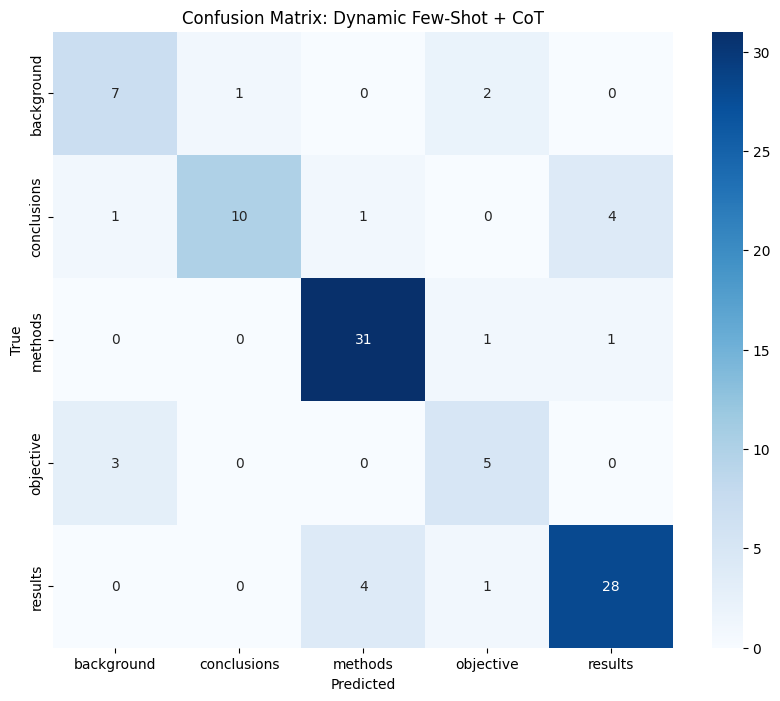

Total Errors: 19

Sample of specific misclassifications:


,Text,True_Label,Predicted_Label
11,The aluminum oxide disc polishing system resulted in less enamel roughness than did the multilaminated carbide bur system .,conclusions,results
13,SDMs prioritized the personal attributes of the person approaching them over professional designation and preferred physician time to be...,conclusions,results
24,Genome sequencing of the BCG strains revealed candidate genes potentially involved in the differential clinical responses .,conclusions,results
27,The main risk factor was the presence of a urinary catheter preoperatively .,conclusions,results
34,We included @ participants .,results,methods
36,The primary end point was change in serum phosphate from baseline to the end of treatment .,methods,objective
37,Relatively homogeneous population of African Americans with hypertensive kidney disease .,conclusions,methods
38,The vaccine efficacy ( VE ) of @ or @ doses of AS@-adjuvanted influenza A ( H@N@ ) vaccine relative to that of @ doses of nonadjuvanted ...,background,objective
44,"There have been several studies of atrial fibrillation ( AF ) over the past decades ; however , data from Chinese patients are scarce .",objective,background
54,We performed a secondary analysis using the Single Ventricle Reconstruction Trial database after excluding patients < @ weeks gestation ...,results,methods


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate Confusion Matrix
cm = confusion_matrix(final_true, all_preds, labels=PUBMED_LABEL_NAMES)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=PUBMED_LABEL_NAMES, yticklabels=PUBMED_LABEL_NAMES, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix: Dynamic Few-Shot + CoT')
plt.show()

# 2. Extract specific errors for qualitative analysis
error_analysis_df = pd.DataFrame({
    'Text': eval_texts[:len(all_preds)],
    'True_Label': final_true,
    'Predicted_Label': all_preds
})

errors = error_analysis_df[error_analysis_df['True_Label'] != error_analysis_df['Predicted_Label']]

print(f"Total Errors: {len(errors)}")
print("\nSample of specific misclassifications:")
display(errors.head(10))

### MIPRO

In [ ]:
import dspy
from dspy.teleprompt import MIPROv2
from sklearn.metrics import accuracy_score, classification_report
from tqdm.auto import tqdm

# 1. Prepare small optimization set (subset of eval to save time/cost)
trainset = []
for i, row in eval_df.head(50).iterrows():
    trainset.append(dspy.Example(texts=row['text'], label=row['label_name']).with_inputs('texts'))

# 2. Define a Simple Module for Single Sentence Optimization
class PubMedClassifier(dspy.Module):
    def __init__(self):
        super().__init__()
        self.predictor = dspy.ChainOfThought("texts -> label")

    def forward(self, texts):
        return self.predictor(texts=texts)

# 3. Define Metric
def accuracy_metric(gold, pred, trace=None):
    if not pred or not hasattr(pred, 'label') or pred.label is None:
        return False
    return gold.label.lower() == pred.label.lower().strip()

# 4. Run MIPROv2 Optimizer
# The 'auto' parameter handles the complexity of the optimization strategy
teleprompter = MIPROv2(metric=accuracy_metric, auto="light")

print("Starting Instruction Optimization with MIPROv2 (Cleaned Args)...")
optimized_pubmed = teleprompter.compile(
    PubMedClassifier(),
    trainset=trainset,
    max_bootstrapped_demos=2,
    max_labeled_demos=2
)

# 5. Evaluate Optimized Model on the full 100-sample eval set
all_preds = []
all_true = eval_df['label_name'].tolist()

print("Evaluating Optimized Model on 100-sample test set...")
for text in tqdm(eval_df['text'].tolist()):
    try:
        res = optimized_pubmed(texts=text)
        pred_label = res.label.lower().strip() if hasattr(res, 'label') else "error"
        all_preds.append(pred_label)
    except Exception as e:
        all_preds.append("error")

acc = accuracy_score(all_true, all_preds)
save_result({"experiment_name": "mipro_optimized_instructions_v3", "accuracy": acc, "timestamp": now_stamp()})

print(f"\nFinal Accuracy after MIPRO Optimization: {acc:.2%}")
print(classification_report(all_true, all_preds))

2026/05/09 07:34:29 INFO dspy.teleprompt.mipro_optimizer_v2: 
RUNNING WITH THE FOLLOWING LIGHT AUTO RUN SETTINGS:
num_trials: 10
minibatch: False
num_fewshot_candidates: 6
num_instruct_candidates: 3
valset size: 40

2026/05/09 07:34:29 INFO dspy.teleprompt.mipro_optimizer_v2: 
==> STEP 1: BOOTSTRAP FEWSHOT EXAMPLES <==
2026/05/09 07:34:29 INFO dspy.teleprompt.mipro_optimizer_v2: These will be used as few-shot example candidates for our program and for creating instructions.

2026/05/09 07:34:29 INFO dspy.teleprompt.mipro_optimizer_v2: Bootstrapping N=6 sets of demonstrations...


Starting Instruction Optimization with MIPROv2 (Cleaned Args)...
Bootstrapping set 1/6
Bootstrapping set 2/6
Bootstrapping set 3/6


 20%|██        | 2/10 [00:00<00:02,  3.91it/s]


Bootstrapped 2 full traces after 2 examples for up to 1 rounds, amounting to 2 attempts.
Bootstrapping set 4/6


 20%|██        | 2/10 [00:00<00:01,  6.57it/s]


...

Average Metric: 32.00 / 40 (80.0%): 100%|██████████| 40/40 [00:00<00:00, 107.64it/s]

2026/05/09 07:53:32 INFO dspy.evaluate.evaluate: Average Metric: 32 / 40 (80.0%)
2026/05/09 07:53:32 INFO dspy.teleprompt.mipro_optimizer_v2: Score: 80.0 with parameters ['Predictor 0: Instruction 1', 'Predictor 0: Few-Shot Set 3'].
2026/05/09 07:53:32 INFO dspy.teleprompt.mipro_optimizer_v2: Scores so far: [5.0, 80.0, 75.0, 77.5, 75.0, 72.5, 75.0, 75.0, 80.0, 75.0, 80.0]
2026/05/09 07:53:32 INFO dspy.teleprompt.mipro_optimizer_v2: Best score so far: 80.0
2026/05/09 07:53:32 INFO dspy.teleprompt.mipro_optimizer_v2: =========================


2026/05/09 07:53:32 INFO dspy.teleprompt.mipro_optimizer_v2: Returning best identified program with score 80.0!



Evaluating Optimized Model on 100-sample test set...


  0%|          | 0/100 [00:00<?, ?it/s]

  [OK] Saved 1 results -> results_incremental.json

Final Accuracy after MIPRO Optimization: 80.00%
              precision    recall  f1-score   support

  background       0.70      0.70      0.70        10
 conclusions       0.90      0.56      0.69        16
     methods       0.82      0.97      0.89        33
   objective       0.71      0.62      0.67         8
     results       0.79      0.82      0.81        33

    accuracy                           0.80       100
   macro avg       0.79      0.74      0.75       100
weighted avg       0.80      0.80      0.79       100



Results saved to: /content/drive/MyDrive/data_selection_showdown/results/mipro_optimization_results.csv


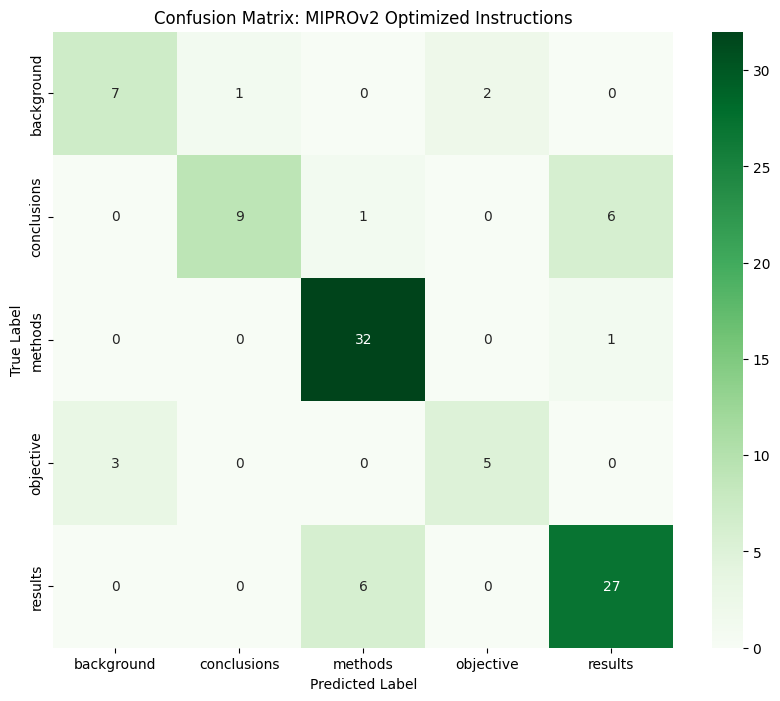


Class-wise performance summary:
              precision    recall  f1-score   support

  background       0.70      0.70      0.70        10
 conclusions       0.90      0.56      0.69        16
     methods       0.82      0.97      0.89        33
   objective       0.71      0.62      0.67         8
     results       0.79      0.82      0.81        33

    accuracy                           0.80       100
   macro avg       0.79      0.74      0.75       100
weighted avg       0.80      0.80      0.79       100



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

# 1. Prepare Dataframe of MIPRO Results
mipro_results_df = pd.DataFrame({
    'text': eval_df['text'].tolist(),
    'true_label': all_true,
    'predicted_label': all_preds
})

# 2. Save results to a CSV file in the results directory
export_path = RESULTS_DIR / "mipro_optimization_results.csv"
mipro_results_df.to_csv(export_path, index=False)
print(f"Results saved to: {export_path}")

# 3. Visualize Confusion Matrix
cm = confusion_matrix(all_true, all_preds, labels=PUBMED_LABEL_NAMES)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=PUBMED_LABEL_NAMES,
    yticklabels=PUBMED_LABEL_NAMES,
    cmap='Greens'
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: MIPROv2 Optimized Instructions')
plt.show()

# 4. Show summary of accuracy per class
print("\nClass-wise performance summary:")
print(classification_report(all_true, all_preds))

In [ ]:
path = r"C:\Users\Dmitry\Downloads\mipro_optimization_results.csv"
df = pd.read_csv(path)
from IPython.display import display

# Randomly sample N rows where predicted_label != true_label for manual inspection
N = 20  # adjust as desired
error_df = df[df['predicted_label'] != df['true_label']].sample(n=min(N, (df['predicted_label'] != df['true_label']).sum()), random_state=42)

print(f"Showing {len(error_df)} model 'errors' for manual ambiguity/error check:")
display(error_df[['text', 'true_label', 'predicted_label']])

Showing 20 model 'errors' for manual ambiguity/error check:


,text,true_label,predicted_label
4,"As concomitant medications , @-aminosalicylic acids , corticosteroids , and thiopurines were administered to @ % , @ % , and @ % of the patients , respectively .",results,methods
95,Recurrence occurs in @ % to @ % of patients .,objective,background
76,"Number and percentage of women who responded to the recall within @ weeks after they had received the recall , irrespective whether they had Pap test conducted .",methods,results
8,"There were @ households ( @,@ individuals ) in intervention villages and @ households ( @,@ individuals ) in control villages .",results,methods
38,The vaccine efficacy ( VE ) of @ or @ doses of AS@-adjuvanted influenza A ( H@N@ ) vaccine relative to that of @ doses of nonadjuvanted influenza A ( H@N@ ) vaccine in children @ months to < @ years of age in a multinational study conducted during @-@ .,background,objective
27,The main risk factor was the presence of a urinary catheter preoperatively .,conclusions,results
56,"The aim of the present study was to investigate several possible predictors of short - and long-term treatment outcome in terms of symptom improvement , based on data collected in the previously conducted treatment trial .",background,objective
13,SDMs prioritized the personal attributes of the person approaching them over professional designation and preferred physician time to be dedicated to patient care .,conclusions,results
96,Fifteen women per group ( n = @ total ) were randomized ; @ per group underwent surgery .,results,methods
90,"Effects of poverty on children 's cognition are mostly mediated through parental education , birth size , growth in the first @ months , and home stimulation in the first @ years .",conclusions,results


### GEPA

In [ ]:
import dspy
import json
import re
from dspy.teleprompt import GEPA
from sklearn.metrics import accuracy_score, classification_report
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

# --- 1. DATA PREPARATION (BATCHED) ---
_, train_subset_df = train_test_split(
    train_df, test_size=100, stratify=train_df['label'], random_state=SEED
)

trainset = []
texts_list = train_subset_df['text'].tolist()
labels_list = [label_name_from_value(l) for l in train_subset_df['label'].tolist()]

for i in range(0, len(texts_list), 5):
    batch_texts = texts_list[i:i+5]
    batch_labels = labels_list[i:i+5]
    if len(batch_texts) == 5:
        formatted_input = "\n".join([f"{idx+1}. {txt}" for idx, txt in enumerate(batch_texts)])
        trainset.append(dspy.Example(
            input_texts=formatted_input,
            target_labels=batch_labels # STRICT ISOLATION: Renamed to avoid .labels() method collision
        ).with_inputs('input_texts'))

# --- 2. SIGNATURE & MODULE DEFINITION ---
class PubMedBatchSignature(dspy.Signature):
    """Classify a list of 5 medical sentences into rhetorical roles."""
    input_texts = dspy.InputField(desc="Numbered list of 5 sentences.")
    predicted_labels = dspy.OutputField(desc="Strict JSON list of exactly 5 labels, e.g., [\"background\", \"objective\", \"methods\", \"results\", \"conclusions\"].")

class PubMedBatchClassifier(dspy.Module):
    def __init__(self):
        super().__init__()
        # Standard CoT bypasses strict Adapter validation errors
        self.predictor = dspy.ChainOfThought(PubMedBatchSignature)

    def forward(self, input_texts):
        return self.predictor(input_texts=input_texts)

# --- 3. GEPA METRIC ---
def gepa_batch_metric(gold, pred, trace=None, pred_name=None, pred_trace=None):
    # EXTRACT DATA using the isolated attribute
    gold_labels = [str(l).lower().strip() for l in gold.target_labels]

    # MANUAL JSON PARSING
    raw_output = str(getattr(pred, 'predicted_labels', ''))
    json_match = re.search(r'\[.*?\]', raw_output, re.DOTALL)

    if json_match:
        try:
            pred_labels = [str(l).strip().lower() for l in json.loads(json_match.group(0))]
        except json.JSONDecodeError:
            pred_labels = ["error"] * 5
    else:
        pred_labels = ["error"] * 5

    # ENFORCE LENGTH
    if len(pred_labels) != 5:
        pred_labels = (pred_labels + ["error"] * 5)[:5]

    # CALCULATE SCORE
    correct_count = sum(1 for g, p in zip(gold_labels, pred_labels) if g == p)
    score = correct_count / 5.0

    # GENERATE REFLECTION FEEDBACK
    if score == 1.0:
        feedback = "Perfect classification."
    else:
        errors = [f"Pos {i+1}: Expected {gold_labels[i]}, got {pred_labels[i]}"
                  for i in range(5) if gold_labels[i] != pred_labels[i]]
        feedback = f"Partial Success ({correct_count}/5). Failures: " + "; ".join(errors)

    return dspy.Prediction(score=score, feedback=feedback)

# --- 4. OPTIMIZATION CONFIGURATION ---
prediction_lm = dspy.LM(model='openai/gemma-4-31b-it', api_base=GOOGLE_OPENAI_BASE_URL, api_key=GOOGLE_API_KEY, num_retries=30)
reflection_lm = dspy.LM(model=f'openai/{DEFAULT_MODEL}', api_base=GOOGLE_OPENAI_BASE_URL, api_key=GOOGLE_API_KEY, num_retries=30)

# Apply global concurrency
dspy.settings.configure(lm=prediction_lm, num_threads=15)

optimizer = GEPA(
    metric=gepa_batch_metric,
    reflection_lm=reflection_lm,
    auto="light",
    reflection_minibatch_size=2,
    skip_perfect_score=True,
    candidate_selection_strategy="pareto"
)

print(f"Compiling Batch GEPA Program... (Trainset Size: {len(trainset)})")
optimized_batch_program = optimizer.compile(
    PubMedBatchClassifier(),
    trainset=trainset
)

# --- 5. EVALUATION ---
all_preds, all_true = [], []
eval_texts = eval_df['text'].tolist()
eval_labels = [label_name_from_value(l) for l in eval_df['label'].tolist()]

print("Evaluating Optimized Batch Model...")
for i in tqdm(range(0, len(eval_texts), 5)):
    batch = eval_texts[i:i+5]
    targets = eval_labels[i:i+5]
    if len(batch) < 5: continue

    try:
        formatted_batch = "\n".join([f"{idx+1}. {txt}" for idx, txt in enumerate(batch)])
        res = optimized_batch_program(input_texts=formatted_batch)

        raw_output = str(getattr(res, 'predicted_labels', ''))
        json_match = re.search(r'\[.*?\]', raw_output, re.DOTALL)

        if json_match:
            try:
                preds = [str(l).strip().lower() for l in json.loads(json_match.group(0))]
            except json.JSONDecodeError:
                preds = ["error"] * 5
        else:
            preds = ["error"] * 5

        if len(preds) != 5:
            preds = (preds + ["error"] * 5)[:5]

        all_preds.extend(preds)
        all_true.extend(targets)
    except Exception:
        all_preds.extend(["error"] * 5)
        all_true.extend(targets)

# --- 6. FINAL REPORT ---
acc = accuracy_score(all_true, all_preds)

save_result({
    "experiment_name": "dspy_gepa_batch_stabilized",
    "accuracy": acc,
    "timestamp": now_stamp()
})

print(f"\nFinal Batched Accuracy: {acc:.2%}")
print(classification_report(all_true, all_preds))

2026/05/09 09:29:31 INFO dspy.teleprompt.gepa.gepa: Running GEPA for approx 460 metric calls of the program. This amounts to 23.00 full evals on the train set.
2026/05/09 09:29:31 WARNING dspy.teleprompt.gepa.gepa: No valset provided; Using trainset as valset. This is useful as an inference-time scaling strategy where you want GEPA to find the best solutions for the provided tasks in the trainset, as it makes GEPA overfit prompts to the provided trainset. In order to ensure generalization and perform well on unseen tasks, please provide separate trainset and valset. Provide the smallest valset that is just large enough to match the downstream task distribution, while keeping trainset as large as possible.
2026/05/09 09:29:31 INFO dspy.teleprompt.gepa.gepa: Using 20 examples for tracking Pareto scores.


Compiling Batch GEPA Program... (Trainset Size: 20)


GEPA Optimization:   0%|          | 0/460 [00:00<?, ?rollouts/s]2026/05/09 09:29:31 INFO dspy.evaluate.evaluate: Average Metric: 0.0 / 20 (0.0%)
2026/05/09 09:29:31 INFO dspy.teleprompt.gepa.gepa: Iteration 0: Base program full valset score: 0.0 over 20 / 20 examples
GEPA Optimization:   4%|▍         | 20/460 [00:00<00:06, 67.71rollouts/s]2026/05/09 09:29:31 INFO dspy.teleprompt.gepa.gepa: Iteration 1: Selected program 0 score: 0.0


Average Metric: 0.00 / 2 (0.0%): 100%|██████████| 2/2 [00:00<00:00, 72.79it/s]

2026/05/09 09:29:31 INFO dspy.evaluate.evaluate: Average Metric: 0.0 / 2 (0.0%)


...

2026/05/09 09:45:43 INFO dspy.evaluate.evaluate: Average Metric: 0.0 / 2 (0.0%)


2026/05/09 09:53:26 INFO dspy.teleprompt.gepa.gepa: Iteration 3: Exception during reflection/proposal: litellm.RateLimitError: RateLimitError: OpenAIException - Error code: 429 - [{'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 500, model: gemini-3.1-flash-lite\nPlease retry in 33.213416169s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_ti

Average Metric: 0.00 / 2 (0.0%): 100%|██████████| 2/2 [00:00<00:00, 59.24it/s]

2026/05/09 09:53:26 INFO dspy.evaluate.evaluate: Average Metric: 0.0 / 2 (0.0%)


KeyboardInterrupt: 

### LLM true labels + setfit probs + cleanlab

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from cleanlab.classification import CleanLearning
from sklearn.preprocessing import LabelEncoder

# 1. Prepare Labels
le = LabelEncoder()
le.fit(PUBMED_LABEL_NAMES)
# We treat the MIPRO LLM predictions as our 'noisy' labels for this task
labels = le.transform(mipro_results_df["predicted_label"].tolist())

# 2. Manual SetFit: Extract Embeddings
# Using the embed_texts helper defined earlier (utilizes fastembed all-MiniLM-L6-v2)
print("Generating text embeddings (manual SetFit step)...")
X_embeddings = embed_texts(mipro_results_df["text"].tolist())

# 3. Fit a classifier to get robust probabilities
# We use Logistic Regression with cross-validation probabilities (multi_class='multinomial')
print("Training Logistic Regression on embeddings...")
clf = LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=SEED)
clf.fit(X_embeddings, labels)

# Get out-of-sample predicted probabilities using Cleanlab's cross-validation wrapper
# This is more robust than just clf.predict_proba
cl = CleanLearning(clf=clf, seed=SEED)

print("Running Cleanlab noise detection...")
# find_label_issues calculates pred_probs internally using cross-validation if we pass the classifier
label_issues = cl.find_label_issues(X=X_embeddings, labels=labels)

# 4. Merge findings back to our dataframe
mipro_results_df['is_label_issue'] = label_issues['is_label_issue'].values
mipro_results_df['label_quality'] = label_issues['label_quality'].values

# Show the most 'suspicious' rows where the LLM prediction might be noisy compared to the data distribution
suspicious_rows = mipro_results_df[mipro_results_df['is_label_issue'] == True].sort_values('label_quality')

print(f"\nDetected {len(suspicious_rows)} potential label issues.")
display(suspicious_rows[['text', 'true_label', 'predicted_label', 'label_quality']].head(10))

Generating text embeddings (manual SetFit step)...
Training Logistic Regression on embeddings...
Running Cleanlab noise detection...

Detected 11 potential label issues.


,text,true_label,predicted_label,label_quality
33,"Subjects in the control and intervention groups showed improvement in their oral health assessments , swallowing abilities and oral intake .",results,results,0.204343
76,"Number and percentage of women who responded to the recall within @ weeks after they had received the recall , irrespective whether they had Pap test conducted .",methods,results,0.228861
10,Patients were stratified into high-risk ( HR ) versus non-high-risk ( non-HR ) cohorts based upon clinical criteria similar to those utilized in the REALISM trial .,methods,methods,0.254674
80,Wilcoxon signed-ranked tests were used to analyse the differences after SR-WBV intervention and sham intervention .,methods,methods,0.281932
87,"Among water-scarce schools , comprehensive WASH improvements were associated with decreased odds of diarrhea ( odds ratio -LSB- OR -RSB- = @ ; @ % confidence interval -LSB- CI -RSB- = @ , @ ) and visiting a clinic ( OR = @ ; @ % CI = @ , @ ) , relative to control schools .",results,results,0.294744
46,"Among these @ patients with T@DM , @ % refused insulin therapy .",results,results,0.296711
17,"The average time required for placement in groups I and II was @ and @ minutes , respectively ( P = @ ) .",results,results,0.298320
24,Genome sequencing of the BCG strains revealed candidate genes potentially involved in the differential clinical responses .,conclusions,results,0.319644
63,Median @-week postinfection VL was @ and @ log copies per milliliter in women assigned to tenofovir gel ( n = @ ) and placebo gel ( n = @ ) ( P = @ ) .,results,results,0.322692
54,We performed a secondary analysis using the Single Ventricle Reconstruction Trial database after excluding patients < @ weeks gestation ( N = @ ) .,results,methods,0.323804


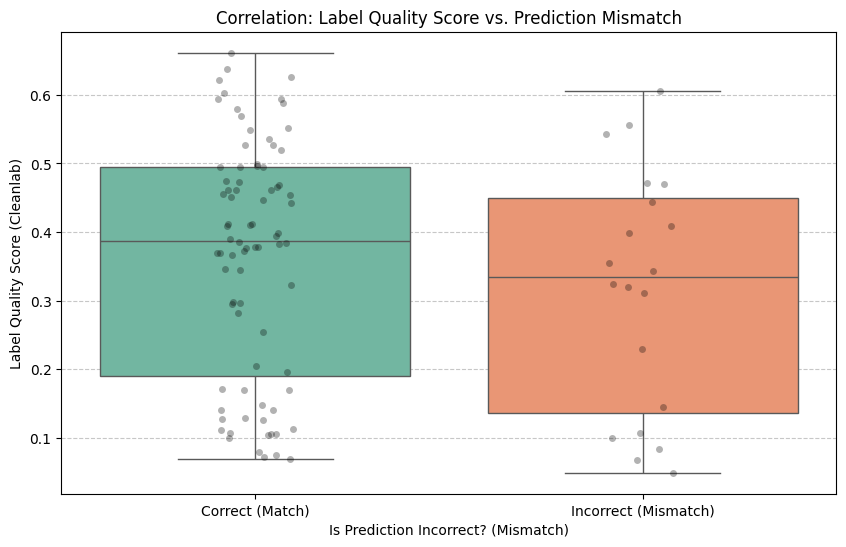

Average Label Quality for Correct Predictions: 0.3633
Average Label Quality for Mismatches (Errors): 0.3164

Point-Biserial Correlation: -0.1096 (p-value: 0.2777)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare data for correlation
# We define a mismatch where true_label != predicted_label
mipro_results_df['is_mismatch'] = mipro_results_df['true_label'] != mipro_results_df['predicted_label']

# 2. Visualize Correlation: Label Quality Score vs. Mismatch
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_mismatch', y='label_quality', data=mipro_results_df, palette='Set2')

# Add individual points to see the distribution density
sns.stripplot(x='is_mismatch', y='label_quality', data=mipro_results_df, color='black', alpha=0.3, jitter=True)

plt.title('Correlation: Label Quality Score vs. Prediction Mismatch')
plt.xlabel('Is Prediction Incorrect? (Mismatch)')
plt.ylabel('Label Quality Score (Cleanlab)')
plt.xticks([0, 1], ['Correct (Match)', 'Incorrect (Mismatch)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Calculate mean scores for report
mean_scores = mipro_results_df.groupby('is_mismatch')['label_quality'].mean()
print(f"Average Label Quality for Correct Predictions: {mean_scores[False]:.4f}")
print(f"Average Label Quality for Mismatches (Errors): {mean_scores[True]:.4f}")

# 4. Optional: Point-Biserial Correlation
from scipy.stats import pointbiserialr
corr, p_val = pointbiserialr(mipro_results_df['is_mismatch'], mipro_results_df['label_quality'])
print(f"\nPoint-Biserial Correlation: {corr:.4f} (p-value: {p_val:.4f})")

### Trained setfit

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Prepare Training Data
print("Extracting embeddings for training set...")
X_train = embed_texts(few_shot_train_df['text'].tolist())
le = LabelEncoder()
y_train = le.fit_transform(few_shot_train_df['label_name'].tolist())

# 2. Train Manual SetFit (Logistic Regression on top of Embeddings)
print("Training classifier...")
clf = LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=SEED)
clf.fit(X_train, y_train)

# 3. Predict Evaluation Set
print("Extracting embeddings for evaluation set...")
X_eval = embed_texts(eval_df['text'].tolist())
y_eval_true = le.transform(eval_df['label_name'].tolist())

print("Generating predictions...")
y_eval_pred = clf.predict(X_eval)

# 4. Results
acc = accuracy_score(y_eval_true, y_eval_pred)
print(f"\nSetFit (Manual) Accuracy: {acc:.2%}")
print("\nClassification Report:")
print(classification_report(y_eval_true, y_eval_pred, target_names=le.classes_))

# Store for comparison
save_result({
    "experiment_name": "manual_setfit_logistic_regression",
    "accuracy": acc,
    "timestamp": now_stamp()
})

Extracting embeddings for training set...
Training classifier...
Extracting embeddings for evaluation set...
Generating predictions...

SetFit (Manual) Accuracy: 48.00%

Classification Report:
              precision    recall  f1-score   support

  background       0.00      0.00      0.00        10
 conclusions       0.00      0.00      0.00        16
     methods       0.43      0.85      0.57        33
   objective       0.00      0.00      0.00         8
     results       0.57      0.61      0.59        33

    accuracy                           0.48       100
   macro avg       0.20      0.29      0.23       100
weighted avg       0.33      0.48      0.38       100

  [OK] Saved 2 results -> results_incremental.json


### SETFIT MORE

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Create a larger stratified training set (200 samples)
_, larger_train_df = train_test_split(
    train_df,
    test_size=2000,
    stratify=train_df['label'],
    random_state=SEED
)
larger_train_df['label_name'] = larger_train_df['label'].apply(label_name_from_value)

print(f"Training with {len(larger_train_df)} samples...")
print(larger_train_df['label_name'].value_counts())

# 2. Extract Embeddings
X_train_large = embed_texts(larger_train_df['text'].tolist())
y_train_large = le.transform(larger_train_df['label_name'].tolist())

# 3. Train Classifier
clf_large = LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=SEED)
clf_large.fit(X_train_large, y_train_large)

# 4. Predict Evaluation Set
y_eval_pred_large = clf_large.predict(X_eval)

# 5. Results
acc_large = accuracy_score(y_eval_true, y_eval_pred_large)
print(f"\nSetFit (200 samples) Accuracy: {acc_large:.2%}")
print("\nClassification Report:")
print(classification_report(y_eval_true, y_eval_pred_large, target_names=le.classes_))

# Store result
save_result({
    "experiment_name": "manual_setfit_200_samples",
    "accuracy": acc_large,
    "timestamp": now_stamp()
})

Training with 2000 samples...
label_name
methods        671
results        656
conclusions    308
background     208
objective      157
Name: count, dtype: int64

SetFit (200 samples) Accuracy: 59.00%

Classification Report:
              precision    recall  f1-score   support

  background       0.20      0.10      0.13        10
 conclusions       0.54      0.44      0.48        16
     methods       0.59      0.88      0.71        33
   objective       0.00      0.00      0.00         8
     results       0.73      0.67      0.70        33

    accuracy                           0.59       100
   macro avg       0.41      0.42      0.40       100
weighted avg       0.54      0.59      0.55       100

  [OK] Saved 4 results -> results_incremental.json


### Per label

In [ ]:
import dspy
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.metrics import accuracy_score, classification_report
from tqdm.auto import tqdm

# 1. Configure the LLM to gemma-4-31b-it
lm = dspy.LM(
    model='openai/gemma-4-31b-it',
    api_base=GOOGLE_OPENAI_BASE_URL,
    api_key=GOOGLE_API_KEY,
    max_tokens=5000,
    num_retries=30
)
dspy.configure(lm=lm)

# 2. Define the Binary Verification Signature
class LabelVerificationSignature(dspy.Signature):
    """Verify if a specific rhetorical label applies to a medical sentence."""
    text = dspy.InputField(desc="The medical sentence to evaluate.")
    target_label = dspy.InputField(desc="The rhetorical role to verify (e.g., Background, Methods, etc.).")
    is_compatible = dspy.OutputField(desc="True if the label is compatible with the text, otherwise False.")

# 3. Implementation of the Verification Logic
def verify_label(text, label_name):
    predictor = dspy.Predict(LabelVerificationSignature)
    res = predictor(text=text, target_label=label_name)
    val = str(res.is_compatible).lower().strip()
    return val.startswith('t') or val == '1' or val == 'yes'

# 4. Evaluation settings
labels_to_check = ["background", "objective", "methods", "results", "conclusions"]
eval_texts = eval_df['text'].tolist()[:20]  # Limit for quick verification
true_labels = eval_df['label_name'].tolist()[:20]

confusion_cases = []
final_filtered_preds = []
final_filtered_true = []

def process_text(idx, text):
    votes = []
    for lbl in labels_to_check:
        votes.append(verify_label(text, lbl))
    return idx, votes

print(f"Starting Multi-Request Verification with gemma-4-31b-it... ")
with ThreadPoolExecutor(max_workers=10) as executor:
    futures = {executor.submit(process_text, i, txt): i for i, txt in enumerate(eval_texts)}

    all_results = [None] * len(eval_texts)
    for future in tqdm(as_completed(futures), total=len(futures)):
        idx, votes = future.result()
        all_results[idx] = votes

# 5. Analysis
for i, votes in enumerate(all_results):
    compatible_labels = [labels_to_check[j] for j, v in enumerate(votes) if v]

    if len(compatible_labels) > 1:
        confusion_cases.append({'text': eval_texts[i], 'true': true_labels[i], 'detected': compatible_labels})
    elif len(compatible_labels) == 1:
        final_filtered_preds.append(compatible_labels[0])
        final_filtered_true.append(true_labels[i])
    else:
        final_filtered_preds.append("none")
        final_filtered_true.append(true_labels[i])

filtered_acc = accuracy_score(final_filtered_true, final_filtered_preds)
print(f"\nEvaluation Summary (gemma-4-31b-it):")
print(f"Total Texts: {len(eval_texts)}")
print(f"Unambiguous Predictions: {len(final_filtered_preds)}")
print(f"Confusion Cases: {len(confusion_cases)}")
print(f"Filtered Accuracy: {filtered_acc:.2%}")

save_result({
    "experiment_name": "gemma_4_verification_confusion_filtered",
    "total_samples": len(eval_texts),
    "filtered_accuracy": filtered_acc
})

Starting Multi-Request Verification with gemma-4-31b-it... 


  0%|          | 0/20 [00:00<?, ?it/s]

KeyboardInterrupt: 

### with prior reasoning

In [ ]:
import dspy
import pandas as pd
import re
import json
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

# 1. First Pass: Comprehensive Reasoning (All labels in one request)
class MultiLabelReasoningSignature(dspy.Signature):
    """Perform a deep analysis of a medical sentence against all 5 rhetorical roles.
    For each label, explain why it might or might not fit based on tense, intent, and data content.
    """
    text = dspy.InputField(desc="The medical sentence to analyze.")
    comprehensive_analysis = dspy.OutputField(desc="Detailed breakdown of compatibility for Background, Objective, Methods, Results, and Conclusions.")

# 2. Second Pass: Objective Verdict
class ObjectiveVerdictSignature(dspy.Signature):
    """Analyze the provided evidence for a sentence and decide on the most objective label.

    CRITICAL INSTRUCTION: If the reasoning for the top two labels is equally strong,
    or if no reasoning provides a definitive link to the rubric, output 'confusing'.
    Do not guess if the evidence is insufficient.
    """
    text = dspy.InputField(desc="The original sentence.")
    reasoning_evidence = dspy.InputField(desc="The multi-label analysis from the first pass.")
    final_label = dspy.OutputField(desc="Exactly one from [background, objective, methods, results, conclusions] OR 'confusing'.")

# 3. LMs Configuration
reasoning_lm = dspy.LM(model='openai/gemma-4-26b-a4b-it', api_base=GOOGLE_OPENAI_BASE_URL, api_key=GOOGLE_API_KEY, max_tokens=1500)
verdict_lm = dspy.LM(model='openai/gemma-4-31b-it', api_base=GOOGLE_OPENAI_BASE_URL, api_key=GOOGLE_API_KEY, max_tokens=500)

# 4. Orchestration Logic
def run_optimized_two_step(text):
    # Pass 1: Reasoning with 26b
    with dspy.context(lm=reasoning_lm):
        reasoner = dspy.Predict(MultiLabelReasoningSignature)
        evidence = reasoner(text=text).comprehensive_analysis

    # Pass 2: Verdict with 31b
    with dspy.context(lm=verdict_lm):
        verdictor = dspy.Predict(ObjectiveVerdictSignature)
        res = verdictor(text=text, reasoning_evidence=evidence)

    return res.final_label.strip().lower(), evidence

# 5. Parallel Execution
eval_subset = eval_df.head(20)
results = []

def process_row(row):
    try:
        pred, evidence = run_optimized_two_step(row['text'])
        return {
            'text': row['text'],
            'true': row['label_name'],
            'pred': pred,
            'evidence': evidence
        }
    except Exception as e:
        return {'text': row['text'], 'true': row['label_name'], 'pred': 'error', 'evidence': str(e)}

print("Executing Optimized Two-Step (26b Reasoning -> 31b Verdict)...")
with ThreadPoolExecutor(max_workers=8) as executor:
    futures = [executor.submit(process_row, row) for _, row in eval_subset.iterrows()]
    for future in tqdm(as_completed(futures), total=len(futures)):
        results.append(future.result())

# 6. Summary
results_df = pd.DataFrame(results)
accuracy = (results_df['true'] == results_df['pred']).mean()
confusion_rate = (results_df['pred'] == 'confusing').mean()

print(f"\nResults Analysis (N={len(results_df)}):")
print(f"Final Accuracy: {accuracy:.2%}")
print(f"Confusion Rate: {confusion_rate:.2%}")

# Show a sample reasoning process
sample = results[0]
print(f"\n--- SAMPLE ANALYSIS ---")
print(f"Text: {sample['text']}")
print(f"True: {sample['true']} | Predicted: {sample['pred']}")
print(f"\nEvidence provided by 26b Model:\n{sample['evidence'][:800]}...")

Executing Two-Step Reasoning + Verdict Architecture...


  0%|          | 0/15 [00:00<?, ?it/s]

2026/05/09 09:04:09 WARNING dspy.clients.lm: LM response was truncated due to exceeding max_tokens=1000. You can inspect the latest LM interactions with `dspy.inspect_history()`. To avoid truncation, consider passing a larger max_tokens when setting up dspy.LM. You may also consider increasing the temperature (currently None)  if the reason for truncation is repetition.
2026/05/09 09:05:20 WARNING dspy.clients.lm: LM response was truncated due to exceeding max_tokens=1000. You can inspect the latest LM interactions with `dspy.inspect_history()`. To avoid truncation, consider passing a larger max_tokens when setting up dspy.LM. You may also consider increasing the temperature (currently None)  if the reason for truncation is repetition.


KeyboardInterrupt: 

### with targetted prompt

In [ ]:
import json
import re
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from openai import OpenAI

# 1. Rubric Definition (Target Prompt Block)
target_prompt_block = """
### CLASSIFICATION RUBRIC: CONTRASTING BORDERLINE CASES

To distinguish between high-overlap categories, apply the following logic:

1. METHODS vs. RESULTS (The "Action-Data" Split)
   - METHODS: Focus on the protocol and researcher intent. If the sentence describes WHAT was done (e.g., "stratified," "performed," "measured," "tests were used"), it is METHODS.
   - RESULTS: Focus on what the world did back. If the sentence describes WHAT was found (e.g., "revealed," "increased," "was @%," "showed improvement"), it is RESULTS.
   - BORDERLINE RULE: A sentence describing the "number of participants who did X" is a RESULT of the recruitment process, even if it feels like a procedural description.

2. RESULTS vs. CONCLUSIONS (The "Fact-Meaning" Split)
   - RESULTS: Hard empirical data. Observations that are true regardless of theory (e.g., "Group A was 10% higher than Group B").
   - CONCLUSIONS: Interpretations, implications, or future-facing statements. Look for hedged language or significance (e.g., "suggests," "may indicate," "is a promising intervention," "is warranted").
   - BORDERLINE RULE: If a sentence reports a discovery (e.g., "revealed candidate genes"), it is a RESULT. If it explains the potential impact of those genes, it is a CONCLUSION.

3. OBJECTIVE vs. BACKGROUND (The "Goal-Context" Split)
   - BACKGROUND: The status quo or the problem in the field.
   - OBJECTIVE: The specific "mission statement" of this study (e.g., "We aimed to," "This study assesses").
"""

# 2. Configuration
VALID_LABELS = {'background', 'objective', 'methods', 'results', 'conclusions'}
batch_size = 5
eval_texts = eval_df['text'].tolist()
true_labels = eval_df['label_name'].tolist()
text_batches = [eval_texts[i:i + batch_size] for i in range(0, len(eval_texts), batch_size)]

client = OpenAI(api_key=GOOGLE_API_KEY, base_url=GOOGLE_OPENAI_BASE_URL, max_retries=30)
TARGET_MODEL = DEFAULT_MODEL # "gemma-4-31b-it"

def process_batch_direct(idx, batch):
    formatted_input = "\n".join([f"{i+1}. {txt}" for i, txt in enumerate(batch)])
    system_msg = f"Classify a list of 5 medical sentences. VALID LABELS: [background, objective, methods, results, conclusions]. Return a JSON LIST containing exactly 5 labels as strings.\n{target_prompt_block}"

    try:
        response = client.chat.completions.create(
            model=TARGET_MODEL,
            messages=[
                {"role": "system", "content": system_msg},
                {"role": "user", "content": f"Classify these 5 sentences and return ONLY a JSON list of 5 labels:\n{formatted_input}"}
            ],
            response_format={"type": "json_object"},
            temperature=0.0
        )

        raw_content = response.choices[0].message.content
        if idx == 0:
            print(f"DEBUG - Batch 0 Raw Output: {raw_content}")

        # Robust extraction: find the actual list inside the response
        # This handles cases where the model includes <thought> tags or extra text
        json_match = re.search(r'\[.*\]', raw_content, re.DOTALL)
        if json_match:
            data = json.loads(json_match.group(0))
        else:
            # Fallback to direct json.loads if no brackets found (unlikely with json_object mode)
            data = json.loads(raw_content)

        preds = []

        if isinstance(data, list):
            preds = [str(p).lower().strip() for p in data]
        elif isinstance(data, dict):
            potential_list = next((v for v in data.values() if isinstance(v, list)), None)
            if potential_list:
                preds = [str(p).lower().strip() for p in potential_list]
            else:
                for i in range(1, 6):
                    val = data.get(str(i), data.get(i, "error"))
                    preds.append(str(val).lower().strip())

        preds = [p if p in VALID_LABELS else "error" for p in preds]
        if len(preds) < len(batch):
            preds += ["error"] * (len(batch) - len(preds))

    except Exception as e:
        if idx == 0: print(f"DEBUG - Error processing batch 0: {e}")
        preds = ["error"] * len(batch)

    return idx, preds[:len(batch)]

# 3. Execution
print(f"Executing direct OpenAI client (Gemma 31B) with robust regex parsing...")
all_indexed_results = []
with ThreadPoolExecutor(max_workers=6) as executor:
    futures = {executor.submit(process_batch_direct, i, b): i for i, b in enumerate(text_batches)}
    for future in tqdm(as_completed(futures), total=len(futures)):
        all_indexed_results.append(future.result())

all_indexed_results.sort(key=lambda x: x[0])
all_preds = [p for idx, batch_preds in all_indexed_results for p in batch_preds]

# 4. Report
acc = accuracy_score(true_labels[:len(all_preds)], all_preds)
save_result({"experiment_name": "direct_openai_gemma_31b_robust_extraction", "accuracy": acc, "timestamp": now_stamp()})

print(f"\nAccuracy: {acc:.2%}")
print(classification_report(true_labels[:len(all_preds)], all_preds))

Executing direct OpenAI client (Gemma 31B) with robust regex parsing...


  0%|          | 0/20 [00:00<?, ?it/s]

DEBUG - Error processing batch 0: Error code: 429 - [{'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 500, model: gemini-3.1-flash-lite\nPlease retry in 14.47378671s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model':

### Centroid fewshot

In [ ]:
import dspy
import json
import re
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min, accuracy_score, classification_report

# 1. Generate Representative Centroids from Training Data
print("Step 1: Sampling training pool and generating embeddings...")
train_pool_df = train_df.sample(n=1000, random_state=SEED)
train_pool_df['label_name'] = train_pool_df['label'].apply(label_name_from_value)
train_embeddings = embed_texts(train_pool_df['text'].tolist())

print("Step 2: Calculating class centroids and selecting representative anchors...")
centroid_examples = []
for label in PUBMED_LABEL_NAMES:
    label_indices = train_pool_df[train_pool_df['label_name'] == label].index
    if len(label_indices) == 0: continue

    # Get embeddings for this specific class
    class_embeddings = train_embeddings[train_pool_df.index.get_indexer(label_indices)]

    # Find the centroid (mean vector)
    centroid = class_embeddings.mean(axis=0).reshape(1, -1)

    # Find the sample closest to the centroid
    closest_idx, _ = pairwise_distances_argmin_min(centroid, class_embeddings)
    representative_text = train_pool_df.loc[label_indices[closest_idx[0]], 'text']

    centroid_examples.append(f"Label: {label.upper()}\nRepresentative Sentence: {representative_text}")

centroid_fewshot_str = "\n\n".join(centroid_examples)
print(f"  -> Generated {len(centroid_examples)} centroid anchors.")

# 2. Signature with Centroid Anchoring
class PubMedCentroidSignature(dspy.Signature):
    """Classify medical sentences. Anchoring examples provided below are mathematical centroids of the dataset categories."""
    input_texts = dspy.InputField(desc="Numbered list of 5 sentences.")
    predicted_labels = dspy.OutputField(desc="JSON list of 5 labels.")

PubMedCentroidSignature.__doc__ += f"\n\n### CENTROID ANCHORS:\n{centroid_fewshot_str}"

class PubMedCentroidClassifier(dspy.Module):
    def __init__(self):
        super().__init__()
        self.predictor = dspy.Predict(PubMedCentroidSignature)

    def forward(self, input_texts):
        return self.predictor(input_texts=input_texts)

# 3. Process 5 Requests (25 sentences)
num_test_samples = 25
eval_subset = eval_df.head(num_test_samples)
batch_size = 5
text_batches = [eval_subset['text'].tolist()[i:i + batch_size] for i in range(0, num_test_samples, batch_size)]

classifier = PubMedCentroidClassifier()
lm = dspy.LM(model=f'openai/{GEMMA26}', api_base=GOOGLE_OPENAI_BASE_URL, api_key=GOOGLE_API_KEY, num_retries=30)

all_preds = []
all_true = eval_subset['label_name'].tolist()

print(f"Step 3: Executing {len(text_batches)} centroid-anchored batch requests...")
for i, batch in enumerate(text_batches):
    print(f"  Processing batch {i+1}/{len(text_batches)}...")
    formatted_input = "\n".join([f"{idx+1}. {txt}" for idx, txt in enumerate(batch)])
    with dspy.context(lm=lm):
        try:
            res = classifier(input_texts=formatted_input)
            raw_output = str(res['predicted_labels'])

            # Attempt JSON parse, fallback to regex
            try:
                extracted = re.search(r'\[.*?\]', raw_output, re.DOTALL).group(0)
                preds = [str(p).strip().lower() for p in json.loads(extracted)]
            except:
                preds = re.findall(r'(background|objective|methods|results|conclusions)', raw_output.lower())
        except Exception as e:
            print(f"    [!] Error in batch {i+1}: {e}")
            preds = ["error"] * batch_size

        # Align lengths
        preds = (preds + ["error"] * batch_size)[:batch_size]
        all_preds.extend(preds)

# 4. Reporting
print("Step 4: Calculating final metrics...")
acc = accuracy_score(all_true, all_preds)
save_result({"experiment_name": "centroid_static_fewshot_5req", "accuracy": acc})

print(f"\nCentroid-Based Accuracy (N=25): {acc:.2%}")
print(classification_report(all_true, all_preds))

Executing 5 centroid-anchored requests...


RateLimitError: litellm.RateLimitError: RateLimitError: OpenAIException - Error code: 429 - [{'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 1500, model: gemma-4-31b\nPlease retry in 11.796601486s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions':

### Two pass: reasoning + label & confidence

In [ ]:
import dspy
import json
import re
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from tqdm.auto import tqdm

from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

# 1. Signatures for Two-Step Forced Elicitation
class ConfidenceReasoningSignature(dspy.Signature):
    """Analyze a medical sentence, comparing it against all rhetorical roles to identify the best fit."""
    text = dspy.InputField()
    reasoning_over_alternatives = dspy.OutputField(desc="Explain why the best label fits and why other labels are less likely.")

class ForcedConfidenceVerdictSignature(dspy.Signature):
    """Based on the reasoning, provide the final label and a numerical confidence score."""
    text = dspy.InputField()
    reasoning = dspy.InputField()
    verdict_json = dspy.OutputField(desc='Strict JSON object: {"predicted_label": "...", "confidence_score": 0.XX}')

# 2. Module Implementation
class ForcedElicitationClassifier(dspy.Module):
    def __init__(self):
        super().__init__()
        self.reasoner = dspy.Predict(ConfidenceReasoningSignature)
        self.verdict = dspy.Predict(ForcedConfidenceVerdictSignature)

    def forward(self, text):
        reasoning_res = self.reasoner(text=text)
        verdict_res = self.verdict(text=text, reasoning=reasoning_res.reasoning_over_alternatives)
        return verdict_res

# 3. Evaluation Setup
lm = dspy.LM(model=f'openai/{DEFAULT_MODEL}', api_base=GOOGLE_OPENAI_BASE_URL, api_key=GOOGLE_API_KEY, max_tokens=5000, num_retries=30)
classifier = ForcedElicitationClassifier()
VALID_LABELS = {'background', 'objective', 'methods', 'results', 'conclusions'}

def process_item(idx, text, true_label):
    try:
        with dspy.context(lm=lm):
            res = classifier(text=text)

        print(res)
        raw_json = str(res.verdict_json)
        json_match = re.search(r'\{.*?\}', raw_json, re.DOTALL)
        if json_match:
            data = json.loads(json_match.group(0))
            pred = str(data.get('predicted_label', 'error')).lower().strip()
            conf = float(data.get('confidence_score', 0.0))
        else:
            pred, conf = "error", 0.0
    except:
        pred, conf = "error", 0.0

    return {"idx": idx, "true": true_label, "pred": pred, "conf": conf}

# 4. Execution (Run on Eval Set)
eval_subset = eval_df.head(50) # Representative sample for performance profiling
results = []

print(f"Running Forced Elicitation on {len(eval_subset)} samples...")
with ThreadPoolExecutor(max_workers=2) as executor:
    futures = [executor.submit(process_item, i, row['text'], row['label_name']) for i, (_, row) in enumerate(eval_subset.iterrows())]
    for future in tqdm(as_completed(futures), total=len(futures)):
        results.append(future.result())

# 5. Data Analysis & Visualization
res_df = pd.DataFrame(results)
res_df['is_correct'] = res_df['true'] == res_df['pred']

plt.figure(figsize=(10, 6))
sns.boxplot(x='is_correct', y='conf', data=res_df, palette='Set1')
sns.stripplot(x='is_correct', y='conf', data=res_df, color='black', alpha=0.3, jitter=True)

plt.title('Forced Elicitation: Confidence vs. Accuracy')
plt.xlabel('Prediction Correctness')
plt.ylabel('Self-Declared Confidence Score')
plt.xticks([0, 1], ['Incorrect', 'Correct'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

acc = res_df['is_correct'].mean()
print(f"Accuracy: {acc:.2%}")
print(f"Mean Confidence (Correct): {res_df[res_df['is_correct']]['conf'].mean():.2f}")
print(f"Mean Confidence (Incorrect): {res_df[~res_df['is_correct']]['conf'].mean():.2f}")

save_result({"experiment_name": "forced_verbalized_elicitation_v1", "accuracy": acc})

### Ensembe of confidence

In [ ]:
import dspy
import pandas as pd
import numpy as np
import json
import re
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.metrics import accuracy_score, classification_report

# 1. Signatures & Module
class VerbalizedConfidenceSignature(dspy.Signature):
    """Classify medical sentences and provide a numerical confidence score (0.0 to 1.0)."""
    text = dspy.InputField()
    verdict = dspy.OutputField(desc='Strict JSON: {"label": "...", "confidence": 0.XX}')

class EnsembleClassifier(dspy.Module):
    def __init__(self):
        super().__init__()
        self.predictor = dspy.Predict(VerbalizedConfidenceSignature)

    def forward(self, text, model_name):
        # Use a specific model context for each call
        res = self.predictor(text=text)
        try:
            raw_json = re.search(r'\{.*?\}', str(res.verdict), re.DOTALL).group(0)
            return json.loads(raw_json)
        except:
            return {"label": "error", "confidence": 0.0}

# 2. Models to Ensemble
MODELS = [
    "openai/gemma-4-31b-it",
    "openai/gemma-3-27b-it",
    "openai/gemma-4-26b-a4b-it"
]

def get_lm(model_path):
    return dspy.LM(model=model_path, api_base=GOOGLE_OPENAI_BASE_URL, api_key=GOOGLE_API_KEY, max_tokens=300, num_retries=30)

# 3. Execution Logic
classifier = EnsembleClassifier()
eval_subset = eval_df.head(20)
ensemble_results = []

def process_row_ensemble(row):
    votes = []
    for m_path in MODELS:
        with dspy.context(lm=get_lm(m_path)):
            res = classifier(text=row['text'], model_name=m_path)
            votes.append({"model": m_path, "label": res['label'].lower().strip(), "conf": float(res['confidence'])})

    # Aggregation
    labels = [v['label'] for v in votes if v['label'] != 'error']
    if not labels: return {"true": row['label_name'], "pred": "error", "avg_conf": 0, "disagreement": True}

    # Majority Vote
    final_pred = max(set(labels), key=labels.count)
    avg_conf = np.mean([v['conf'] for v in votes])
    disagreement = len(set(labels)) > 1

    return {
        "text": row['text'],
        "true": row['label_name'],
        "pred": final_pred,
        "avg_conf": avg_conf,
        "disagreement": disagreement,
        "raw_votes": votes
    }

print(f"Running SLM-LLM Verbalized Ensemble (N={len(eval_subset)})... ")
with ThreadPoolExecutor(max_workers=5) as executor:
    futures = [executor.submit(process_row_ensemble, row) for _, row in eval_subset.iterrows()]
    for future in tqdm(as_completed(futures), total=len(futures)):
        ensemble_results.append(future.result())

# 4. Analysis
ens_df = pd.DataFrame(ensemble_results)
acc = accuracy_score(ens_df['true'], ens_df['pred'])

print(f"\nEnsemble Accuracy: {acc:.2%}")
print(f"Risk Flags (Disagreements): {ens_df['disagreement'].sum()} / {len(ens_df)}")

# Calibration check: Accuracy where confidence is high vs low
high_conf_mask = ens_df['avg_conf'] > 0.8
if high_conf_mask.any():
    print(f"Accuracy (High Confidence): {accuracy_score(ens_df[high_conf_mask]['true'], ens_df[high_conf_mask]['pred']):.2%}")

display(ens_df[['true', 'pred', 'avg_conf', 'disagreement']].head(10))